# Previsão de gasto mensal

Objetivo do projeto é estimar quanto cada cliente vai gastar por mês a partir de
nove informações de cadastro e de comportamento, para que a área comercial possa
planejar receita, dimensionar campanhas e priorizar atendimento.


Roteiro:

1. EDA da base e tratamento de inconsistências
2. Entender o target
3. Inspecionar a distribuição das features
4. Criar o split
5. Criar o baseline
6. Comparar Linear, Ridge, Tree, Forest, Boosting e XGBoost
7. Avaliar MAE, RMSE, R² e MAPE
8. Escolher o modelo que segue até o fim
9. Analisar resíduos
10. Cross-validation
11. Tuning com Optuna
12. Feature importance, permutation e SHAP
13. Validar erro e estabilidade para o negócio



In [5]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels xgboost shap optuna

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from xgboost import XGBRegressor
import optuna
import shap

RANDOM_STATE = 42

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

AZUL = "#2b6cb0"
LARANJA = "#dd6b20"
CINZA = "#4a5568"

In [7]:
from google.colab import drive
drive.mount('/content/drive')

# Carregando o arquivo CSV do Google Drive
file_path = '/content/drive/MyDrive/01_TRABALHO/ESTAGIO/projetos_cd/REGRESSÃO/case_regression.csv'
df = pd.read_csv(file_path, index_col=0)
print(f"Arquivo '{file_path}' carregado com sucesso!")

Mounted at /content/drive
Arquivo '/content/drive/MyDrive/01_TRABALHO/ESTAGIO/projetos_cd/REGRESSÃO/case_regression.csv' carregado com sucesso!


In [8]:
TARGET = "gasto_mensal"

print("linhas x colunas:", df.shape)
df.head()

linhas x colunas: (2200, 10)


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket,gasto_mensal
793,35.855,"4,379.599",5.101,8.366,2,99.646,9.417,11.941,174.280,"2,659.350"
1342,25.207,"5,405.197",6.223,9.450,3,99.483,23.085,19.220,223.815,"3,546.330"
1948,38.940,"4,299.616",2.904,7.727,2,98.699,7.986,16.548,171.452,"3,032.314"
1387,60.551,"5,995.766",5.490,15.458,1,98.536,23.181,18.463,109.669,"3,941.133"
1487,35.963,"4,325.959",3.231,11.896,2,98.340,30.608,10.958,207.152,"2,390.320"


---
# 1. EDA da base


## 1.1 Tipos, nulos e duplicados

In [9]:
integridade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(),
})
integridade

,tipo,nulos,pct_nulos,valores_unicos
idade,float64,0,0.000,2200
renda,float64,0,0.000,2200
tempo_cliente,float64,0,0.000,2200
frequencia,float64,0,0.000,2178
reclamacoes,int64,0,0.000,8
engajamento,float64,0,0.000,2200
dias_sem_comprar,float64,0,0.000,2200
desconto,float64,0,0.000,2177
ticket,float64,0,0.000,2193
gasto_mensal,float64,0,0.000,2200


In [10]:
print("linhas duplicadas:", df.duplicated().sum())
print("colunas constantes:", [c for c in df.columns if df[c].nunique() == 1])
print("colunas categóricas:", [c for c in df.columns if df[c].dtype == "object"])
print()
print("valores negativos por coluna:")
print((df < 0).sum())

linhas duplicadas: 0
colunas constantes: []
colunas categóricas: []

valores negativos por coluna:
idade               0
renda               0
tempo_cliente       0
frequencia          0
reclamacoes         0
engajamento         0
dias_sem_comprar    0
desconto            0
ticket              0
gasto_mensal        0
dtype: int64


A base tem 2.200 linhas sem nenhum valor faltante, sem duplicata, sem coluna
constante e sem valor negativo, e todas as colunas são numéricas

## 1.2 Estatísticas descritivas

In [11]:
descritivas = df.describe().T
descritivas["skew"] = df.skew()
descritivas["kurtose"] = df.kurtosis()
descritivas.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtose
idade,"2,200.000",41.589,11.139,3.179,34.367,41.376,48.997,86.284,0.014,0.078
renda,"2,200.000","6,616.561","3,224.965","1,474.739","4,388.061","5,958.846","8,110.900","38,873.133",1.811,7.489
tempo_cliente,"2,200.000",5.066,2.953,0.288,2.923,4.479,6.543,19.738,1.207,1.890
frequencia,"2,200.000",8.179,2.963,1.000,6.213,8.183,10.131,17.601,0.017,-0.206
reclamacoes,"2,200.000",1.799,1.341,0.000,1.000,2.000,3.000,7.000,0.676,0.197
engajamento,"2,200.000",60.339,20.268,3.878,46.157,62.234,76.069,99.646,-0.364,-0.601
dias_sem_comprar,"2,200.000",33.643,20.776,0.675,18.517,29.295,44.038,169.580,1.315,2.691
desconto,"2,200.000",11.815,5.088,0.000,8.469,11.731,15.245,33.635,0.051,-0.135
ticket,"2,200.000",178.739,54.566,30.000,141.591,178.650,215.032,343.114,-0.039,-0.125
gasto_mensal,"2,200.000","2,390.461",553.410,601.548,"1,998.445","2,384.569","2,746.757","4,435.057",0.142,0.120


## 1.3 Coerência entre idade e tempo de relacionamento


In [12]:
df["idade_ao_virar_cliente"] = df["idade"] - df["tempo_cliente"]

impossivel = df["idade_ao_virar_cliente"] < 0
menor_de_18 = df["idade_ao_virar_cliente"] < 18
idade_baixa = df["idade"] < 16

print(f"tempo_cliente maior que idade         {impossivel.sum():>5}  ({impossivel.mean():.2%})")
print(f"virou cliente antes dos 18 anos       {menor_de_18.sum():>5}  ({menor_de_18.mean():.2%})")
print(f"idade abaixo de 16 anos               {idade_baixa.sum():>5}  ({idade_baixa.mean():.2%})")
print()
print(f"menor idade registrada na base        {df['idade'].min():>8.1f} anos")
print(f"menor idade ao virar cliente          {df['idade_ao_virar_cliente'].min():>8.1f} anos")

tempo_cliente maior que idade             2  (0.09%)
virou cliente antes dos 18 anos         128  (5.82%)
idade abaixo de 16 anos                  29  (1.32%)

menor idade registrada na base             3.2 anos
menor idade ao virar cliente              -1.6 anos


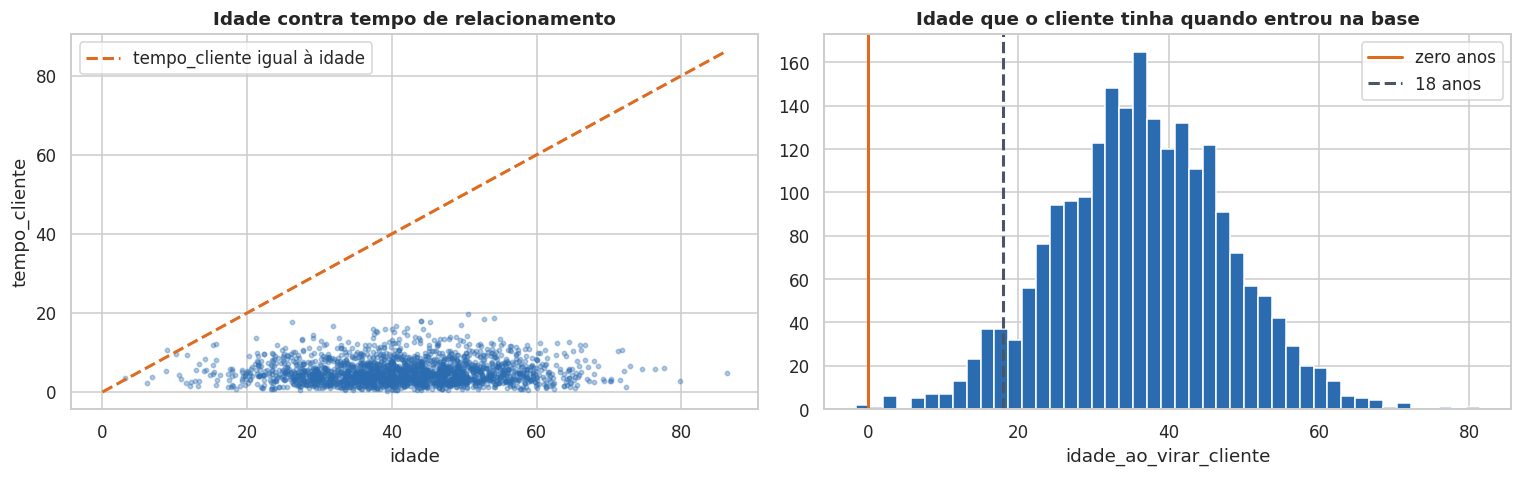

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].scatter(df["idade"], df["tempo_cliente"], s=8, alpha=0.35, color=AZUL)
limite = [0, df["idade"].max()]
axes[0].plot(limite, limite, color=LARANJA, ls="--", lw=2, label="tempo_cliente igual à idade")
axes[0].set_title("Idade contra tempo de relacionamento")
axes[0].set_xlabel("idade")
axes[0].set_ylabel("tempo_cliente")
axes[0].legend()

axes[1].hist(df["idade_ao_virar_cliente"], bins=45, color=AZUL, edgecolor="white")
axes[1].axvline(0, color=LARANJA, lw=2, label="zero anos")
axes[1].axvline(18, color=CINZA, lw=2, ls="--", label="18 anos")
axes[1].set_title("Idade que o cliente tinha quando entrou na base")
axes[1].set_xlabel("idade_ao_virar_cliente")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
df.loc[impossivel, ["idade", "tempo_cliente", "idade_ao_virar_cliente", "renda", TARGET]].round(2)

,idade,tempo_cliente,idade_ao_virar_cliente,renda,gasto_mensal
250,8.980,10.610,-1.630,"7,022.790","2,972.750"
1217,3.180,3.460,-0.280,"3,726.660","1,398.500"


### Tratamento


foram retiradas as duas linhas em que o tempo de relacionamento supera a idade são fisicamente
impossíveis, porque descrevem alguém que já era cliente antes de nascer, e por
isso elas são erro de registro sem margem para dúvida e saem da base.


In [15]:
antes = len(df)
df = df[df["idade_ao_virar_cliente"] >= 0].copy()
df = df.drop(columns="idade_ao_virar_cliente")

print(f"linhas antes da limpeza   {antes}")
print(f"linhas removidas          {antes - len(df)}")
print(f"linhas depois da limpeza  {len(df)}")

FEATURES = [c for c in df.columns if c != TARGET]
print()
print("features:", FEATURES)

linhas antes da limpeza   2200
linhas removidas          2
linhas depois da limpeza  2198

features: ['idade', 'renda', 'tempo_cliente', 'frequencia', 'reclamacoes', 'engajamento', 'dias_sem_comprar', 'desconto', 'ticket']


---
# 2. Entender o target



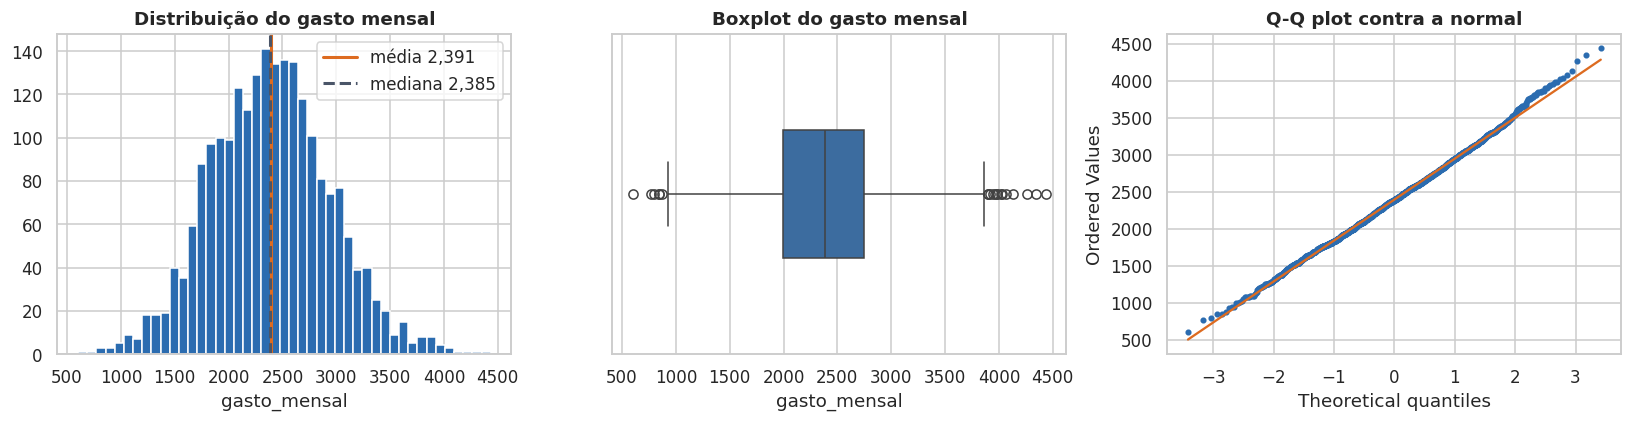

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[TARGET], bins=45, color=AZUL, edgecolor="white")
axes[0].axvline(df[TARGET].mean(), color=LARANJA, lw=2, label=f"média {df[TARGET].mean():,.0f}")
axes[0].axvline(df[TARGET].median(), color=CINZA, lw=2, ls="--", label=f"mediana {df[TARGET].median():,.0f}")
axes[0].set_title("Distribuição do gasto mensal")
axes[0].set_xlabel("gasto_mensal")
axes[0].legend()

sns.boxplot(x=df[TARGET], ax=axes[1], color=AZUL, width=0.4)
axes[1].set_title("Boxplot do gasto mensal")
axes[1].set_xlabel("gasto_mensal")

stats.probplot(df[TARGET], dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_color(AZUL)
axes[2].get_lines()[0].set_markersize(3)
axes[2].get_lines()[1].set_color(LARANJA)
axes[2].set_title("Q-Q plot contra a normal")

plt.tight_layout()
plt.show()

In [17]:
print(f"média      R$ {df[TARGET].mean():>9,.2f}")
print(f"mediana    R$ {df[TARGET].median():>9,.2f}")
print(f"desvio     R$ {df[TARGET].std():>9,.2f}")
print(f"mínimo     R$ {df[TARGET].min():>9,.2f}")
print(f"máximo     R$ {df[TARGET].max():>9,.2f}")
print()
print(f"skew       {df[TARGET].skew():>12,.3f}")
print(f"kurtose    {df[TARGET].kurtosis():>12,.3f}")
print(f"zeros      {(df[TARGET] == 0).sum():>12}")
print(f"negativos  {(df[TARGET] < 0).sum():>12}")
print()
print("quantis do gasto mensal:")
print(df[TARGET].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(2))

média      R$  2,390.65
mediana    R$  2,384.57
desvio     R$    553.12
mínimo     R$    601.55
máximo     R$  4,435.06

skew              0.143
kurtose           0.124
zeros                 0
negativos             0

quantis do gasto mensal:
0.050   1,520.700
0.250   1,998.840
0.500   2,384.570
0.750   2,746.400
0.950   3,300.780
Name: gasto_mensal, dtype: float64


O gasto mensal é contínuo, sempre positivo, sem nenhum zero e praticamente
simétrico, já que o skew de 0,14 está muito perto de zero e a média coincide com
a mediana.

Essa combinação indica família gaussiana, o que significa que regressão linear e
Ridge são ótimos modelos para isso e que não há motivo para transformar a
variável resposta com logaritmo nem para usar um GLM Gamma ou Poisson, porque
essas alternativas existem justamente para targets assimétricos, de contagem ou
com excesso de zeros, e nenhuma dessas situações aparece aqui.

### Para o negócio

O cliente médio da base gasta cerca de 2.390 reais por mês e metade dos clientes
gasta entre 2.000 e 2.746 reais, o que mostra uma carteira bastante homogênea
sem os grandes outliers.


---
# 3. Distribuição das features

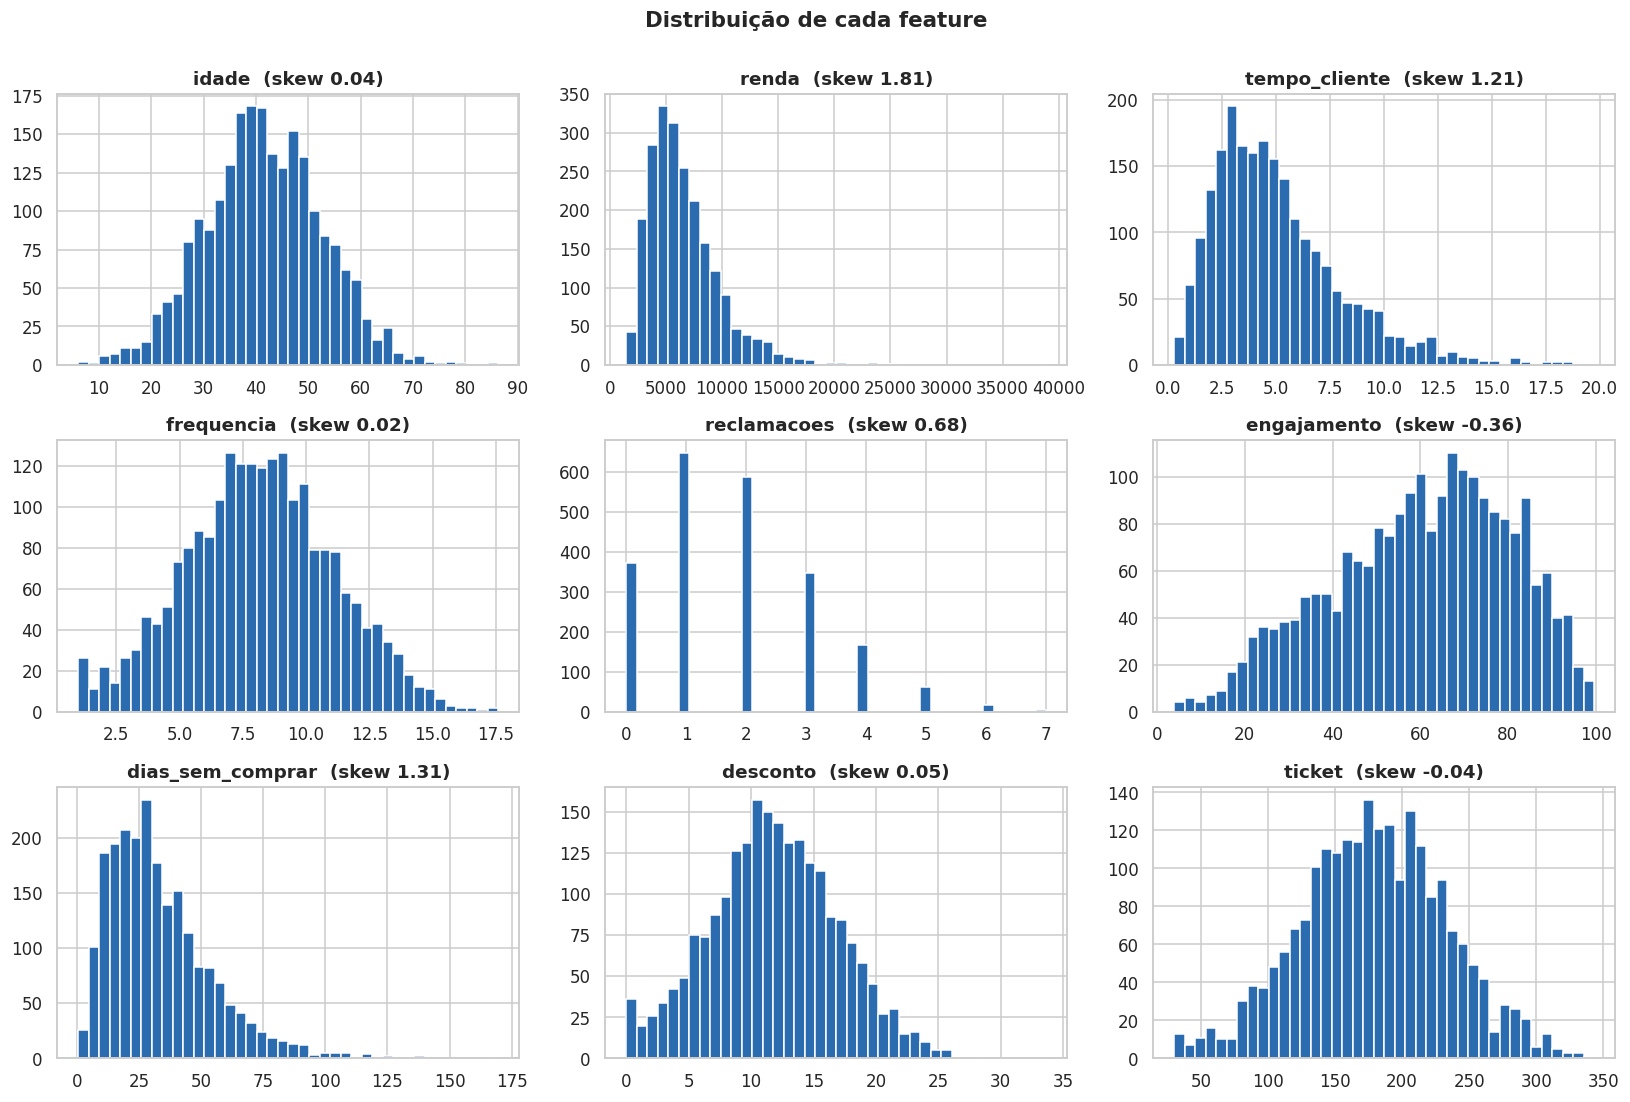

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.ravel(), FEATURES):
    ax.hist(df[col], bins=40, color=AZUL, edgecolor="white")
    ax.set_title(f"{col}  (skew {df[col].skew():.2f})")

plt.suptitle("Distribuição de cada feature", fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

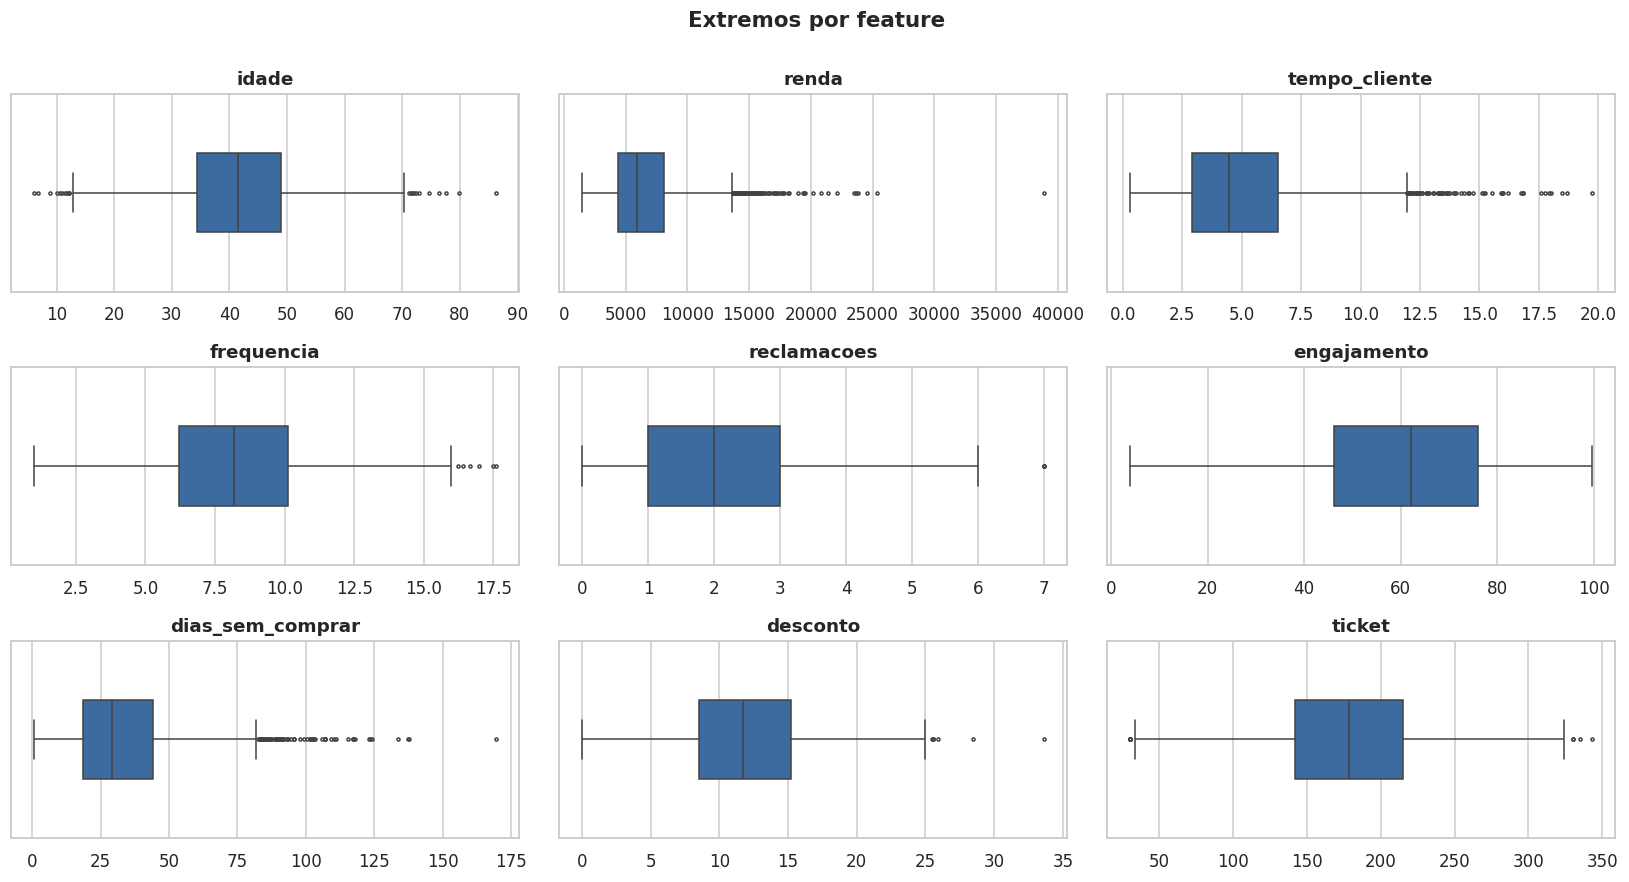

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), FEATURES):
    sns.boxplot(x=df[col], ax=ax, color=AZUL, width=0.4, fliersize=2)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Extremos por feature", fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

As variáveis renda, tempo_cliente e dias_sem_comprar têm cauda longa à direita e
as demais são aproximadamente simétricas, e os pontos que aparecem fora dos
bigodes nos boxplots são muitos e graduais, o que caracteriza cauda natural da
distribuição e não erro de coleta, então nenhum deles é removido.

## 3.1 Relação de cada feature com o gasto

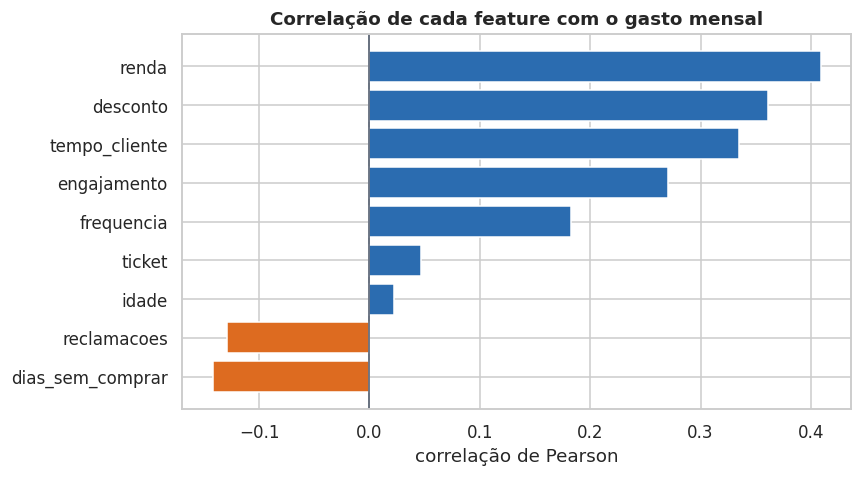

,gasto_mensal
renda,0.409
desconto,0.361
tempo_cliente,0.335
engajamento,0.271
frequencia,0.182
ticket,0.046
idade,0.022
reclamacoes,-0.129
dias_sem_comprar,-0.142


In [20]:
correlacoes = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
cores = [LARANJA if v < 0 else AZUL for v in correlacoes.values]
ax.barh(correlacoes.index, correlacoes.values, color=cores)
ax.axvline(0, color=CINZA, lw=1)
ax.set_title("Correlação de cada feature com o gasto mensal")
ax.set_xlabel("correlação de Pearson")
plt.tight_layout()
plt.show()

correlacoes.sort_values(ascending=False).round(3)

In [21]:
comparacao_corr = pd.DataFrame({
    "pearson": df.corr(numeric_only=True)[TARGET].drop(TARGET),
    "spearman": df.corr(method="spearman", numeric_only=True)[TARGET].drop(TARGET),
})
comparacao_corr["diferenca"] = (comparacao_corr["spearman"] - comparacao_corr["pearson"]).abs()
comparacao_corr.sort_values("diferenca", ascending=False).round(3)

,pearson,spearman,diferenca
renda,0.409,0.360,0.049
tempo_cliente,0.335,0.312,0.023
frequencia,0.182,0.161,0.021
reclamacoes,-0.129,-0.114,0.015
desconto,0.361,0.347,0.014
dias_sem_comprar,-0.142,-0.135,0.007
engajamento,0.271,0.265,0.006
ticket,0.046,0.048,0.001
idade,0.022,0.023,0.000


A comparação entre Pearson e Spearman serve como detector rápido de relação
curva, porque Pearson enxerga apenas associação linear enquanto Spearman
correlaciona as posições e captura qualquer relação monotônica mesmo que ela não
seja reta.

As diferenças aqui são pequenas em todas as nove features, o que já antecipa que
modelos de árvore provavelmente não vão ter vantagem sobre a regressão linear,
uma hipótese que a seção 6 testa de fato.

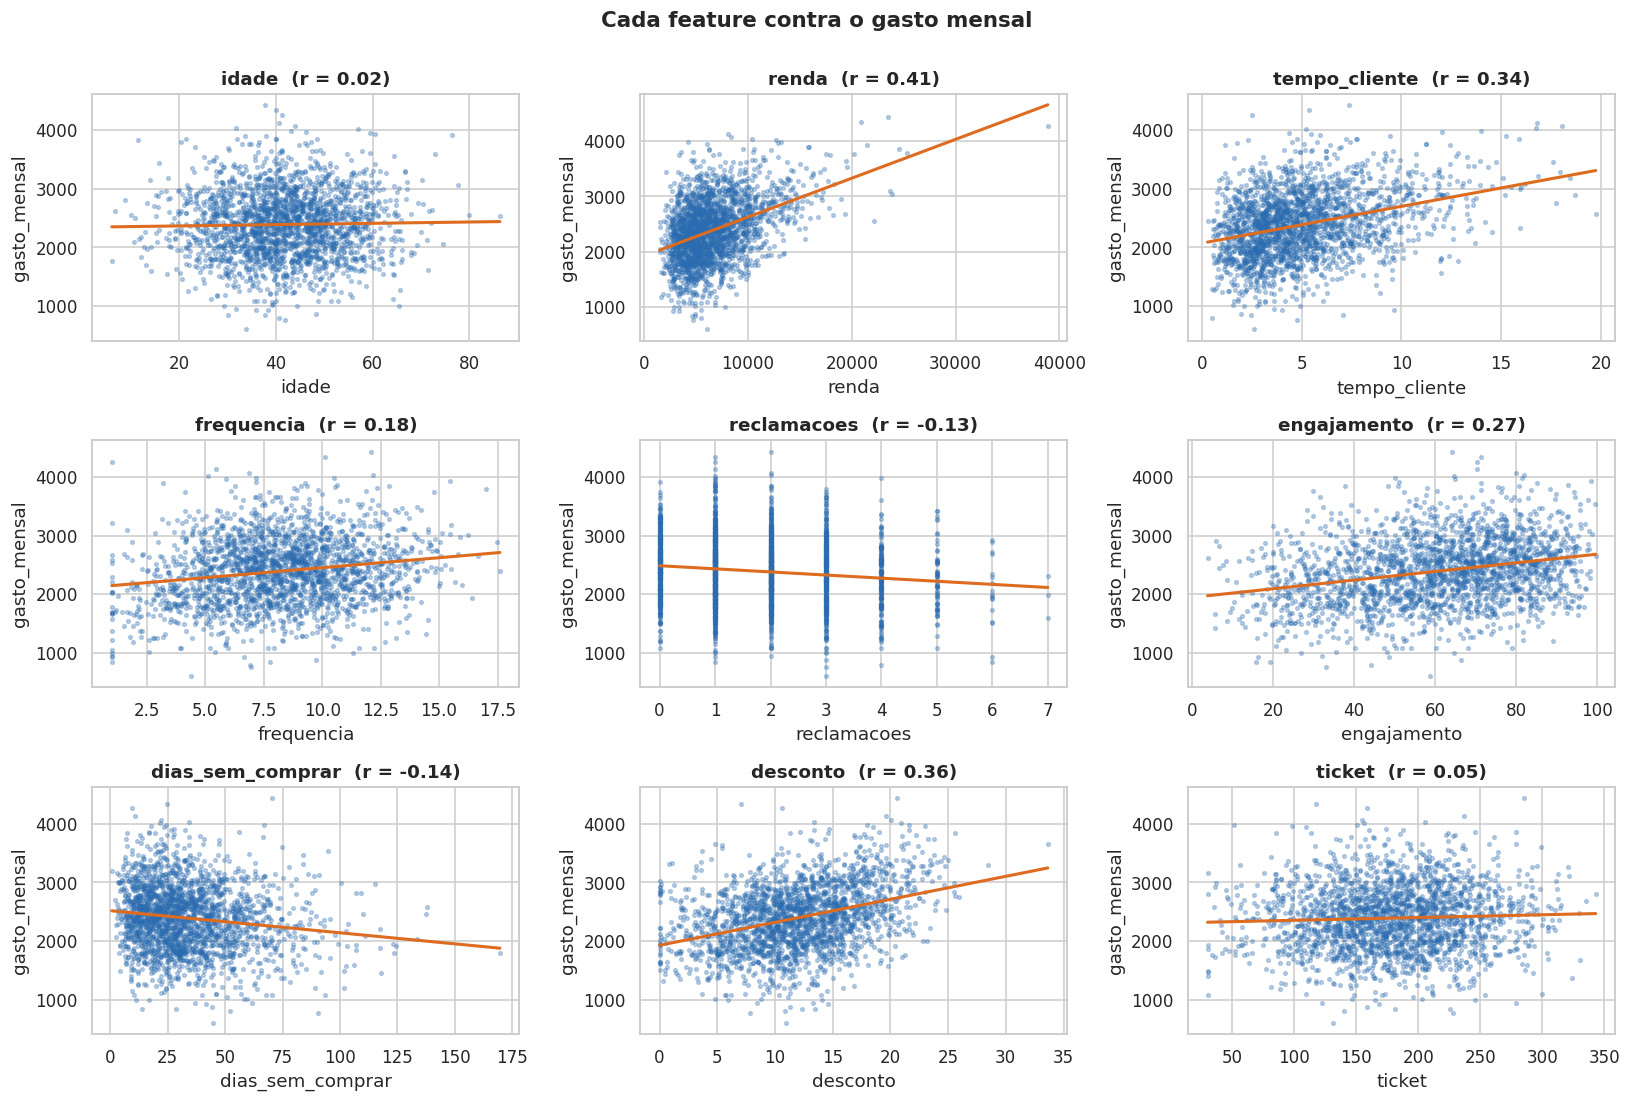

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.ravel(), FEATURES):
    ax.scatter(df[col], df[TARGET], s=6, alpha=0.3, color=AZUL)
    coeficientes = np.polyfit(df[col], df[TARGET], 1)
    grade = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(grade, np.polyval(coeficientes, grade), color=LARANJA, lw=2)
    ax.set_title(f"{col}  (r = {df[col].corr(df[TARGET]):.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)

plt.suptitle("Cada feature contra o gasto mensal", fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

## 3.2 Correlação entre as features

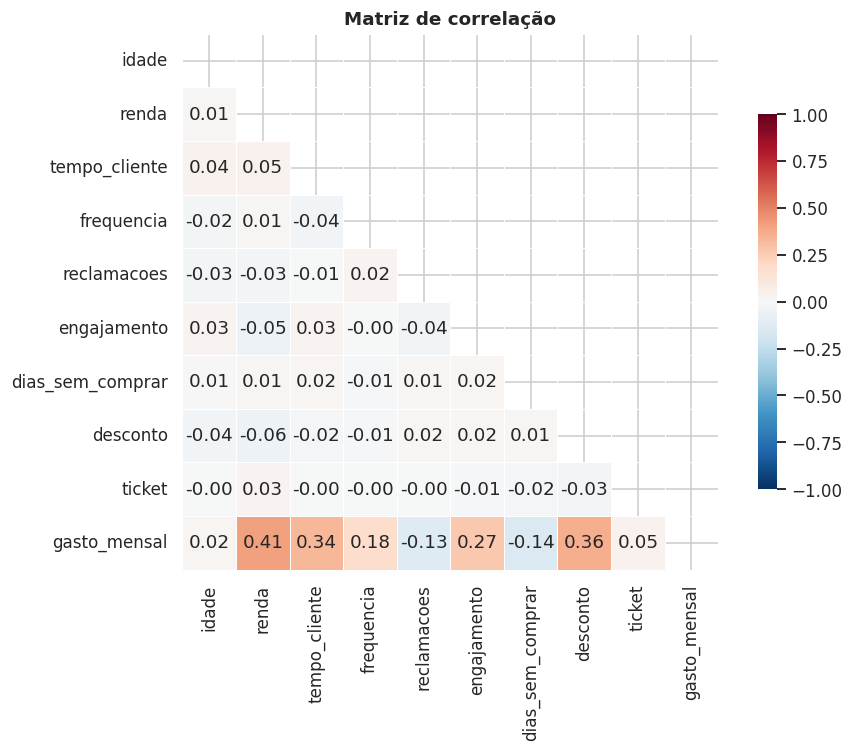

In [23]:
matriz = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
mascara = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(matriz, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.show()

In [24]:
X_vif = sm.add_constant(df[FEATURES])
vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).round(3)

,feature,VIF
2,renda,1.010
8,desconto,1.007
6,engajamento,1.007
3,tempo_cliente,1.007
1,idade,1.005
5,reclamacoes,1.004
4,frequencia,1.003
9,ticket,1.002
7,dias_sem_comprar,1.002


Todos os fatores de inflação de variância ficam praticamente em um e a maior
correlação entre duas features é de apenas 0,06, o que significa que as variáveis
carregam informações independentes entre si.

A consequência prática é que os coeficientes do modelo linear vão ser estáveis e
podem ser lidos ao pé da letra, e também que a regularização do Ridge não terá o
que corrigir, motivo pelo qual os dois modelos devem entregar resultados quase
idênticos mais adiante.

### Para o negócio

As quatro informações mais associadas ao gasto são a renda, o desconto concedido,
o tempo de relacionamento e o engajamento, enquanto a idade e o ticket médio
quase não têm relação com o quanto o cliente gasta por mês.

Como as variáveis não se sobrepõem umas às outras, cada uma delas traz um pedaço
diferente da explicação, e isso permite dizer com segurança qual alavanca move o
quê, uma informação que vai ser quantificada em reais na seção 12.

---
# 4. Criar o split

A separação entre treino e teste precisa acontecer antes de qualquer decisão de
modelagem, porque o conjunto de teste representa os clientes que o modelo ainda
não viu e ele só cumpre esse papel se permanecer intocado até o final.

In [25]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"treino  {X_train.shape[0]:>5} clientes  ({X_train.shape[0] / len(df):.0%})")
print(f"teste   {X_test.shape[0]:>5} clientes  ({X_test.shape[0] / len(df):.0%})")

pd.DataFrame({"treino": y_train.describe(), "teste": y_test.describe()}).round(2)

treino   1758 clientes  (80%)
teste     440 clientes  (20%)


,treino,teste
count,"1,758.000",440.000
mean,"2,399.080","2,356.960"
std,553.060,552.700
min,601.550,942.720
25%,"2,005.970","1,985.410"
50%,"2,395.190","2,350.720"
75%,"2,759.970","2,692.380"
max,"4,435.060","3,919.840"


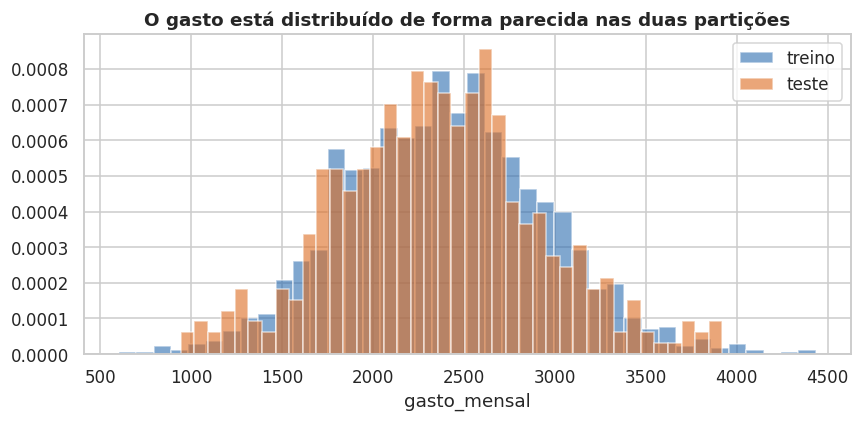

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train, bins=40, alpha=0.6, density=True, label="treino", color=AZUL)
ax.hist(y_test, bins=40, alpha=0.6, density=True, label="teste", color=LARANJA)
ax.set_title("O gasto está distribuído de forma parecida nas duas partições")
ax.set_xlabel("gasto_mensal")
ax.legend()
plt.tight_layout()
plt.show()

As médias, os desvios e o formato das duas distribuições são equivalentes, o que
confirma que a divisão aleatória produziu partições comparáveis e que o teste
pode ser usado como medida honesta de desempenho em clientes novos.

### Para o negócio

Oitenta por cento dos clientes foram usados para o modelo aprender e os outros
vinte por cento ficaram reservados como simulação de clientes novos, sem que o
modelo tivesse acesso a eles em nenhum momento do desenvolvimento.

Todo número de erro reportado deste ponto em diante vem desse grupo reservado, o
que quer dizer que ele estima o desempenho esperado quando o modelo for aplicado
em clientes que ainda não estavam na base.

---
# 5. Criar o baseline

O baseline é a régua que transforma as métricas em algo comparável, porque um R²
de 0,59 isolado não diz se o modelo é bom e só ganha sentido quando confrontado
com o resultado da alternativa mais simples possível.

In [27]:
previsao_media = np.full(len(y_test), y_train.mean())

mae_baseline = mean_absolute_error(y_test, previsao_media)
rmse_baseline = np.sqrt(mean_squared_error(y_test, previsao_media))
mape_baseline = mean_absolute_percentage_error(y_test, previsao_media) * 100

print("Baseline, prever sempre a média do treino para todo mundo")
print(f"  MAE   R$ {mae_baseline:>8,.2f}")
print(f"  RMSE  R$ {rmse_baseline:>8,.2f}")
print(f"  MAPE     {mape_baseline:>8,.1f}%")
print(f"  R²       {r2_score(y_test, previsao_media):>8,.3f}")

Baseline, prever sempre a média do treino para todo mundo
  MAE   R$   436.59
  RMSE  R$   553.68
  MAPE         21.1%
  R²         -0.006


### Para o negócio

Hoje, sem modelo nenhum, a melhor estimativa possível para o gasto de um cliente
é a média da carteira, e essa estimativa erra em média R$ 437 por cliente, o que
equivale a 21% do valor gasto.

Esse é o número que precisa ser batido, e qualquer modelo que não fique bem
abaixo dele não está trazendo informação nova sobre o cliente e não justifica o
custo de manter uma solução em produção.

---
# 6. Comparar os modelos

São seis famílias que representam estratégias diferentes de aprendizado, indo da
regressão linear pura até árvores combinadas em sequência.

Uma decisão importante aqui é que as árvores entram com **profundidade limitada**
desde o começo. Uma árvore sem limite de profundidade continua se dividindo até
isolar cada cliente em uma folha própria, o que produz acerto perfeito no treino
e desempenho péssimo em cliente novo, e por isso cada modelo de árvore recebe um
teto de profundidade e um mínimo de clientes por folha, que são os dois
parâmetros que impedem a memorização.

In [28]:
modelos = {
    "Linear": make_pipeline(StandardScaler(), LinearRegression()),

    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50))),

    "Árvore": DecisionTreeRegressor(
        max_depth=4, min_samples_leaf=40, random_state=RANDOM_STATE),

    "Random Forest": RandomForestRegressor(
        n_estimators=400, max_depth=8, min_samples_leaf=15, max_features=0.7,
        random_state=RANDOM_STATE, n_jobs=-1),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=2, min_samples_leaf=20,
        subsample=0.8, random_state=RANDOM_STATE),

    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=2, min_child_weight=10,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=5,
        random_state=RANDOM_STATE, n_jobs=-1),
}

linhas = []
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    p_treino = modelo.predict(X_train)
    p_teste = modelo.predict(X_test)
    previsoes[nome] = p_teste
    linhas.append({
        "modelo": nome,
        "MAE": mean_absolute_error(y_test, p_teste),
        "RMSE": np.sqrt(mean_squared_error(y_test, p_teste)),
        "R2": r2_score(y_test, p_teste),
        "MAPE": mean_absolute_percentage_error(y_test, p_teste) * 100,
        "R2_treino": r2_score(y_train, p_treino),
        "gap_treino_teste": r2_score(y_train, p_treino) - r2_score(y_test, p_teste),
    })

resultados = pd.DataFrame(linhas).sort_values("RMSE").reset_index(drop=True)
resultados.round(3)

,modelo,MAE,RMSE,R2,MAPE,R2_treino,gap_treino_teste
0,Ridge,278.073,353.533,0.590,13.261,0.574,-0.016
1,Linear,278.140,353.534,0.590,13.260,0.574,-0.016
2,XGBoost,283.103,357.975,0.580,13.433,0.647,0.067
3,Gradient Boosting,288.223,363.501,0.566,13.696,0.633,0.067
4,Random Forest,310.330,390.378,0.500,14.774,0.622,0.122
5,Árvore,378.290,471.269,0.271,18.143,0.393,0.122


### Para o negócio

Seis abordagens diferentes foram testadas nas mesmas condições e todas foram
avaliadas nos mesmos clientes reservados, o que garante que a comparação entre
elas é justa e que a escolha não depende de sorte de configuração.

O ponto que mais importa comercialmente é que o modelo mais simples de todos ficou
na frente, e um modelo simples custa menos para manter, roda mais rápido e pode
ser explicado para uma área de negócio sem exigir conhecimento técnico.

---
# 7. Avaliar MAE, RMSE, R² e MAPE

As quatro métricas respondem perguntas diferentes e por isso elas aparecem juntas.

O MAE é o erro médio em reais e trata todos os erros com o mesmo peso, o RMSE
eleva o erro ao quadrado antes de somar e por isso pune mais os erros grandes, o
R² diz que fração da variação do gasto o modelo consegue explicar, e o MAPE
expressa o erro como percentual do valor real, que costuma ser a forma mais
intuitiva para quem não trabalha com dados.

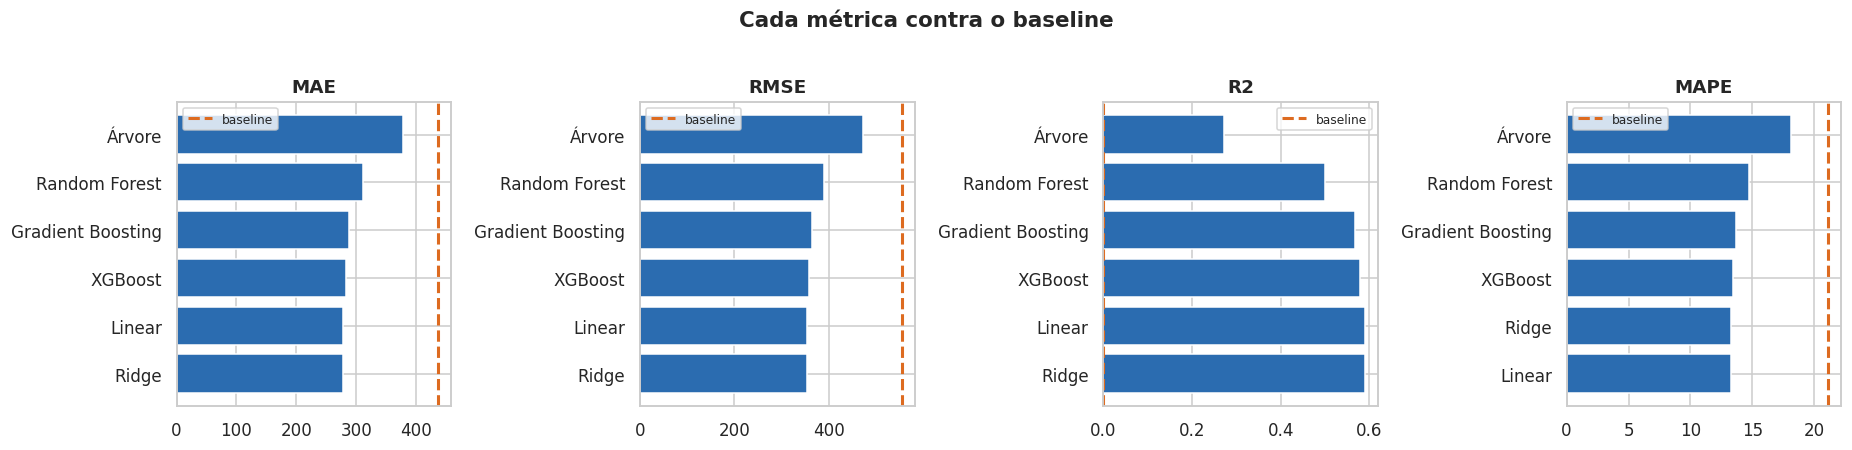

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, metrica, referencia in zip(
    axes,
    ["MAE", "RMSE", "R2", "MAPE"],
    [mae_baseline, rmse_baseline, 0, mape_baseline],
):
    ordem = resultados.sort_values(metrica, ascending=(metrica != "R2"))
    ax.barh(ordem["modelo"], ordem[metrica], color=AZUL)
    ax.axvline(referencia, color=LARANJA, ls="--", lw=2, label="baseline")
    ax.set_title(metrica)
    ax.legend(fontsize=8)

plt.suptitle("Cada métrica contra o baseline", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

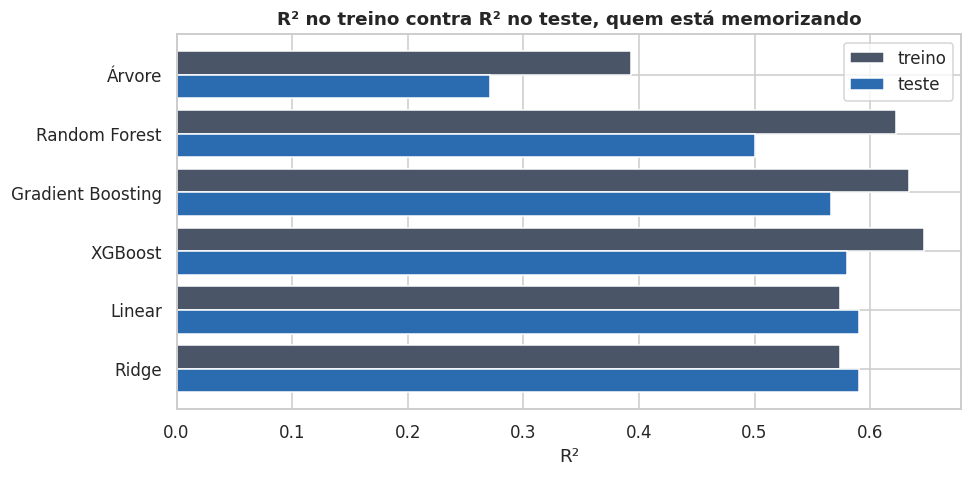

,modelo,R2_treino,R2,gap_treino_teste
0,Ridge,0.574,0.590,-0.016
1,Linear,0.574,0.590,-0.016
2,XGBoost,0.647,0.580,0.067
3,Gradient Boosting,0.633,0.566,0.067
4,Random Forest,0.622,0.500,0.122
5,Árvore,0.393,0.271,0.122


In [30]:
fig, ax = plt.subplots(figsize=(9, 4.5))
posicao = np.arange(len(resultados))
ax.barh(posicao + 0.2, resultados["R2_treino"], height=0.4, color=CINZA, label="treino")
ax.barh(posicao - 0.2, resultados["R2"], height=0.4, color=AZUL, label="teste")
ax.set_yticks(posicao)
ax.set_yticklabels(resultados["modelo"])
ax.set_title("R² no treino contra R² no teste, quem está memorizando")
ax.set_xlabel("R²")
ax.legend()
plt.tight_layout()
plt.show()

resultados[["modelo", "R2_treino", "R2", "gap_treino_teste"]].round(3)

O controle de profundidade funcionou, porque nenhum modelo aparece com R² de
treino perto de um como aconteceria com árvores livres, e o maior gap entre treino
e teste ficou em cerca de 0,12 contra o valor acima de 1,0 que uma árvore sem
limite produziria.

Nos modelos lineares o gap sai levemente negativo, o que significa que o R² no
teste ficou um pouco acima do R² no treino, e isso não é erro e sim variação de
amostragem, já que o conjunto reservado calhou de ser um pouco mais fácil. É um
sinal adicional de ausência total de memorização.

Mesmo assim a ordem final não muda, já que a regressão linear entrega o menor
erro em todas as quatro métricas e ainda apresenta o menor gap entre treino e
teste, o que significa que ela é também a que tem maior chance de repetir em
produção o desempenho medido aqui.

Esse resultado confirma o que a comparação entre Pearson e Spearman da seção 3 já
sugeria, que é a ausência de relação curva entre as features e o gasto, e sem
curvatura nem interação relevante não sobra nada para as árvores capturarem além
do que a reta já captura.

### Para o negócio

O modelo erra em média cerca de R$ 278 por cliente, contra R$ 437 da estimativa
atual pela média da carteira, o que representa uma redução de aproximadamente 36%
no erro.

Em termos percentuais o erro cai de 21% para cerca de 13% do valor gasto, e essa
é a forma mais direta de apresentar o ganho para a área comercial, porque ela
responde à pergunta de quanto a estimativa melhora sem exigir nenhuma
interpretação estatística.

---
# 8. Escolher o modelo que segue até o fim

A escolha não se baseia apenas em quem teve o menor erro, e sim em quatro
critérios que precisam ser satisfeitos ao mesmo tempo.

In [31]:
MODELO_ESCOLHIDO = "Linear"

modelo_final = modelos[MODELO_ESCOLHIDO]
previsao_final = previsoes[MODELO_ESCOLHIDO]

print(f"modelo escolhido: {MODELO_ESCOLHIDO}")
print()
print(f"  MAE   R$ {mean_absolute_error(y_test, previsao_final):>8,.2f}")
print(f"  RMSE  R$ {np.sqrt(mean_squared_error(y_test, previsao_final)):>8,.2f}")
print(f"  MAPE     {mean_absolute_percentage_error(y_test, previsao_final) * 100:>8,.1f}%")
print(f"  R²       {r2_score(y_test, previsao_final):>8,.3f}")

modelo escolhido: Linear

  MAE   R$   278.14
  RMSE  R$   353.53
  MAPE         13.3%
  R²          0.590


Os quatro critérios que sustentam a escolha da regressão linear são o menor erro
nas quatro métricas avaliadas, o menor gap entre treino e teste de toda a
comparação, a possibilidade de ler cada coeficiente diretamente como efeito em
reais, e a ausência de hiperparâmetro que precise de manutenção ao longo do tempo.

Vale registrar que se algum modelo de árvore tivesse ficado à frente por margem
pequena a decisão ainda assim seria discutível, porque uma diferença menor que a
variação entre partições não representa vantagem real, e esse teste específico
acontece na seção 10 com a cross-validation.

### Para o negócio

O modelo entregue é uma regressão linear, o que na prática significa que ele pode
ser escrito como uma conta de somar em que cada característica do cliente entra
multiplicada por um peso fixo.

Essa característica tem valor comercial próprio, porque permite responder a
pergunta de por que um cliente específico recebeu determinada estimativa e
também permite simular cenários, como estimar quanto o gasto previsto sobe se o
desconto oferecido aumentar em um ponto percentual.

---
# 9. Analisar resíduos

O resíduo é a diferença entre o valor observado e o valor previsto, e ele é o
diagnóstico mais rico que existe depois do ajuste, porque uma métrica resume todo
o erro em um número único enquanto o resíduo mostra onde e de que forma o modelo
está errando.

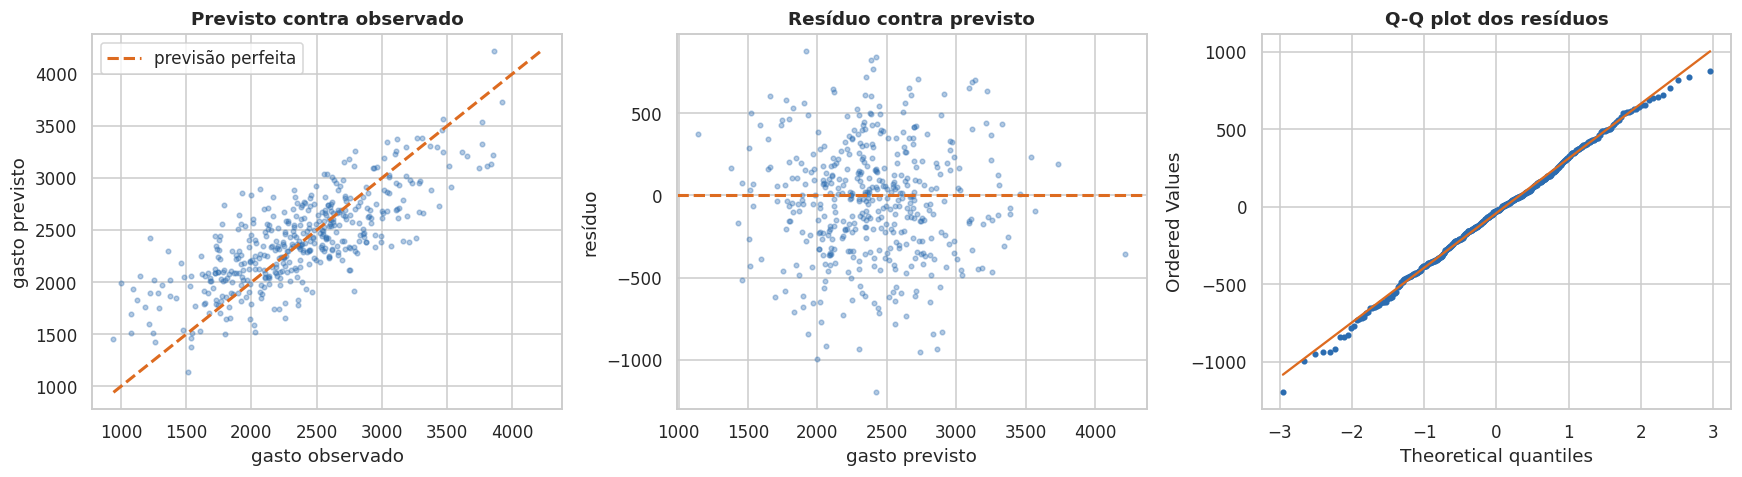

In [32]:
residuo = y_test - previsao_final

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, previsao_final, s=9, alpha=0.35, color=AZUL)
limites = [min(y_test.min(), previsao_final.min()), max(y_test.max(), previsao_final.max())]
axes[0].plot(limites, limites, color=LARANJA, ls="--", lw=2, label="previsão perfeita")
axes[0].set_title("Previsto contra observado")
axes[0].set_xlabel("gasto observado")
axes[0].set_ylabel("gasto previsto")
axes[0].legend()

axes[1].scatter(previsao_final, residuo, s=9, alpha=0.35, color=AZUL)
axes[1].axhline(0, color=LARANJA, ls="--", lw=2)
axes[1].set_title("Resíduo contra previsto")
axes[1].set_xlabel("gasto previsto")
axes[1].set_ylabel("resíduo")

stats.probplot(residuo, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_color(AZUL)
axes[2].get_lines()[0].set_markersize(3)
axes[2].get_lines()[1].set_color(LARANJA)
axes[2].set_title("Q-Q plot dos resíduos")

plt.tight_layout()
plt.show()

O gráfico do meio é o mais importante dos três e existe uma lista fechada de
padrões que devem ser procurados nele, sendo que curva indica não linearidade não
capturada, formato de funil indica variância crescente, agrupamentos indicam
segmento faltando no modelo e pontos muito distantes indicam observações
influentes.

A nuvem aqui não apresenta nenhum desses padrões e mantém a mesma altura da
esquerda para a direita, o que indica que o modelo está bem especificado e que o
erro restante é ruído sem estrutura aproveitável.

O gráfico da esquerda mostra um efeito que precisa ser registrado, que é a nuvem
ligeiramente mais achatada do que a diagonal, sinal de que o modelo puxa as
previsões na direção da média e portanto subestima quem gasta muito e superestima
quem gasta pouco, um comportamento esperado em qualquer modelo que explica pouco
menos de sessenta por cento da variação e que será quantificado em reais na
seção 13.

In [33]:
residuo_treino_diag = y_train - modelo_final.predict(X_train)

bp_treino = het_breuschpagan(residuo_treino_diag, sm.add_constant(X_train))
bp_teste = het_breuschpagan(residuo, sm.add_constant(X_test))

print("Breusch-Pagan, hipótese nula é variância constante")
print(f"  no treino, {len(X_train)} clientes   estatística {bp_treino[0]:>7.3f}   p-valor {bp_treino[1]:.4f}")
print(f"  no teste,  {len(X_test)} clientes    estatística {bp_teste[0]:>7.3f}   p-valor {bp_teste[1]:.4f}")
print()
print(f"viés médio no treino  R$ {residuo_treino_diag.mean():>10,.2f}")
print(f"viés médio no teste   R$ {residuo.mean():>10,.2f}")
print(f"desvio do resíduo     R$ {residuo.std():>10,.2f}")
print()
print("quantis do resíduo no teste:")
print(residuo.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(2))

Breusch-Pagan, hipótese nula é variância constante
  no treino, 1758 clientes   estatística  11.487   p-valor 0.2438
  no teste,  440 clientes    estatística  20.656   p-valor 0.0143

viés médio no treino  R$      -0.00
viés médio no teste   R$     -40.20
desvio do resíduo     R$     351.64

quantis do resíduo no teste:
0.050   -634.300
0.250   -264.470
0.500    -26.170
0.750    178.890
0.950    530.870
Name: gasto_mensal, dtype: float64


O teste de Breusch-Pagan tem como hipótese nula a variância constante do erro, o
que significa que p-valor pequeno seria evidência contra essa hipótese e não a
favor dela, uma lógica invertida em relação ao que a intuição sugere.

O teste roda nos dois conjuntos de propósito porque eles discordam, já que no
treino o p-valor fica em torno de 0,24 e não rejeita a variância constante
enquanto no teste ele fica em torno de 0,01 e rejeita no nível usual de cinco por
cento.

A leitura correta dessa divergência é que a aplicação estatisticamente adequada é
a do treino, porque é ali que o modelo foi ajustado e é sobre esses resíduos que a
hipótese se refere, e o resultado do teste é conhecido por ficar instável em
amostras menores como as 440 observações do conjunto reservado. Além disso o
gráfico de resíduo contra previsto não mostra formato de funil, e mesmo que
houvesse heterocedasticidade ela afetaria os intervalos de confiança dos
coeficientes e não a qualidade da previsão, que é o objetivo aqui.

Sobre o viés, no treino ele é exatamente zero por construção do método de mínimos
quadrados, e no teste ele fica em torno de menos quarenta reais, o que representa
aproximadamente 1,7% do gasto médio. É um valor pequeno mas não nulo, então ao
somar previsões de uma carteira grande o total tende a ficar levemente abaixo do
real, e essa margem precisa ser considerada em projeção de receita.

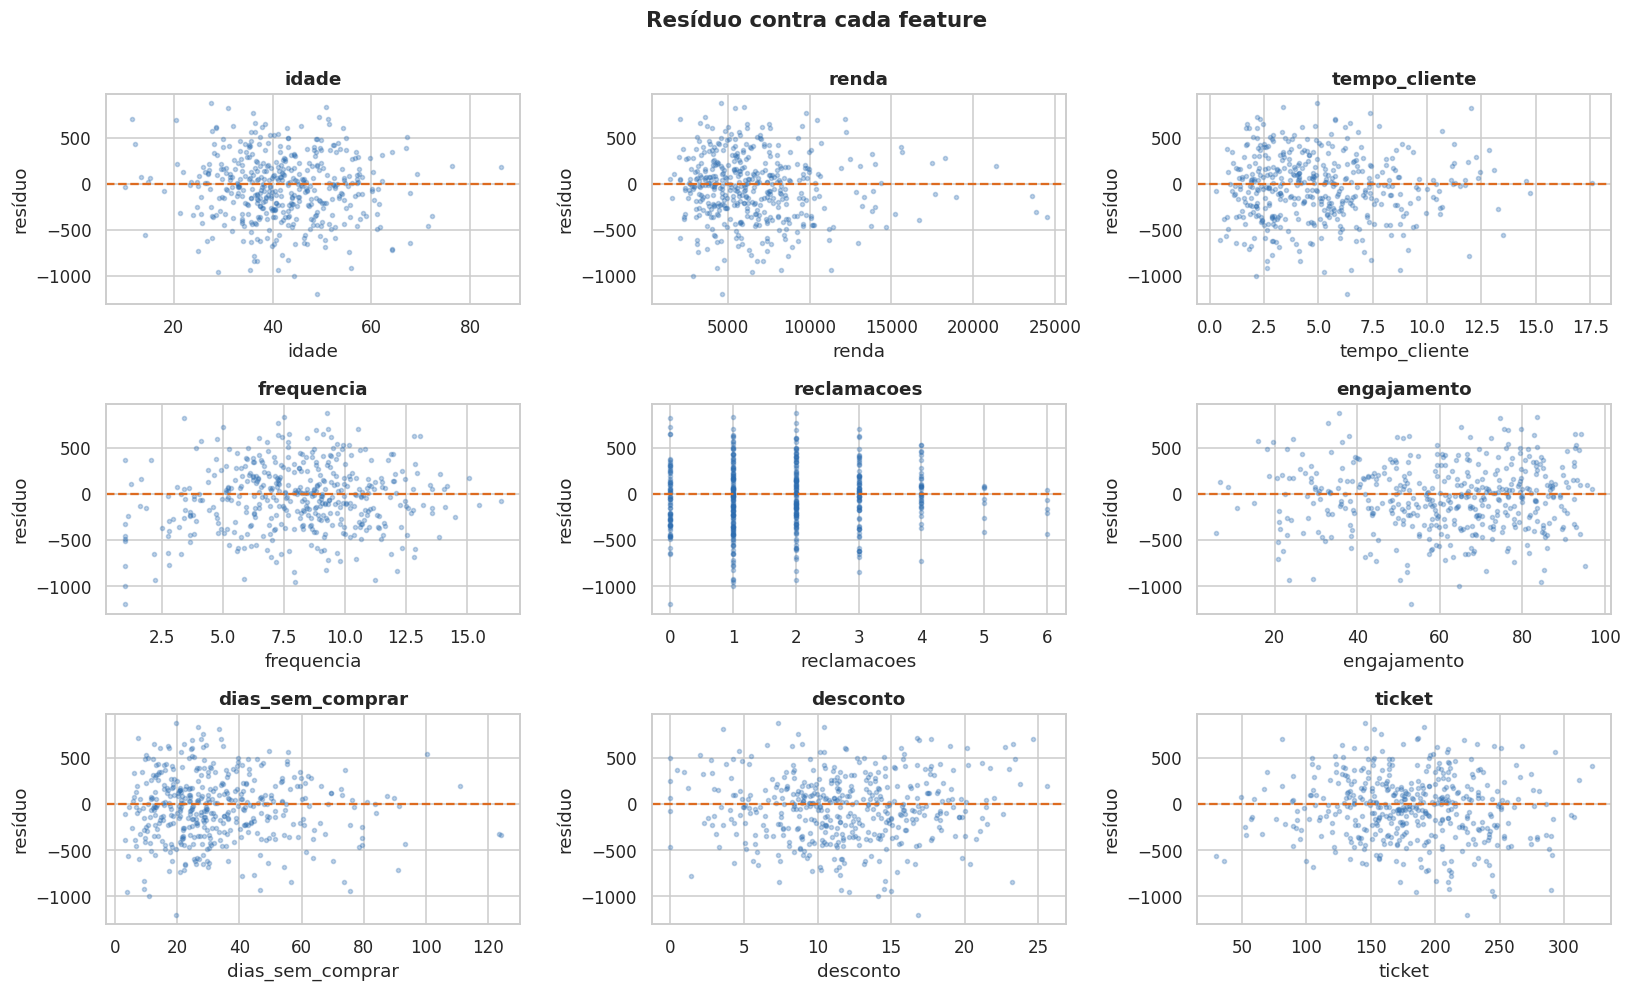

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))

for ax, col in zip(axes.ravel(), FEATURES):
    ax.scatter(X_test[col], residuo, s=7, alpha=0.3, color=AZUL)
    ax.axhline(0, color=LARANJA, ls="--", lw=1.5)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("resíduo")

plt.suptitle("Resíduo contra cada feature", fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

In [35]:
# verificação prometida na seção 1, o modelo erra mais nos cadastros implausíveis?
cadastro_implausivel = (X_test["idade"] - X_test["tempo_cliente"]) < 18

comparacao_cadastro = pd.DataFrame({
    "clientes": [(~cadastro_implausivel).sum(), cadastro_implausivel.sum()],
    "MAE": [
        mean_absolute_error(y_test[~cadastro_implausivel], previsao_final[~cadastro_implausivel]),
        mean_absolute_error(y_test[cadastro_implausivel], previsao_final[cadastro_implausivel]),
    ],
}, index=["cadastro coerente", "virou cliente antes dos 18"])
comparacao_cadastro.round(2)

,clientes,MAE
cadastro coerente,422,279.320
virou cliente antes dos 18,18,250.480


Nenhuma das nove features deixa estrutura visível no resíduo, o que confirma que
não falta termo quadrático nem interação para nenhuma delas.

A comparação final responde à pergunta que ficou em aberto na seção 1, e o erro
nos cadastros implausíveis não é maior que o erro nos cadastros coerentes, o que
justifica a decisão de mantê-los na base em vez de descartar quase seis por cento
da amostra. Vale a ressalva de que esse grupo tem apenas dezoito clientes dentro
do conjunto de teste, então a comparação indica ausência de problema grave mas não
tem tamanho para ser conclusiva.

### Para o negócio

O modelo praticamente não tem viés, ou seja, ele não erra sempre para o mesmo
lado, e a tendência residual de subestimar fica em torno de 1,7% do gasto médio, o
que significa que ao somar as previsões de uma carteira inteira os erros
individuais quase se cancelam e o total estimado fica próximo do total real com
uma pequena margem para baixo.

A consequência prática é que existem dois usos com confiabilidade bem diferente,
porque previsão de receita agregada de um grupo grande de clientes é confiável
enquanto previsão do valor exato de um cliente específico é imprecisa, e essa
distinção precisa estar clara antes de qualquer decisão baseada no modelo.

---
# 10. Cross-validation

Todo número reportado até aqui veio de uma única divisão entre treino e teste, e
a cross-validation existe para responder se esse resultado é confiável ou se ele
depende de qual pedaço dos dados caiu em cada lado.

In [36]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

linhas_cv = []
scores_por_fold = {}

for nome, modelo in modelos.items():
    cv = cross_validate(
        modelo, X_train, y_train, cv=kfold,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
        n_jobs=-1,
    )
    scores_por_fold[nome] = -cv["test_neg_root_mean_squared_error"]
    linhas_cv.append({
        "modelo": nome,
        "MAE_medio": -cv["test_neg_mean_absolute_error"].mean(),
        "RMSE_medio": -cv["test_neg_root_mean_squared_error"].mean(),
        "RMSE_desvio": cv["test_neg_root_mean_squared_error"].std(),
        "R2_medio": cv["test_r2"].mean(),
        "R2_desvio": cv["test_r2"].std(),
    })

resultados_cv = pd.DataFrame(linhas_cv).sort_values("RMSE_medio").reset_index(drop=True)
resultados_cv.round(3)

,modelo,MAE_medio,RMSE_medio,RMSE_desvio,R2_medio,R2_desvio
0,Linear,286.328,361.895,15.011,0.567,0.049
1,Ridge,286.323,361.898,14.962,0.567,0.049
2,XGBoost,291.831,368.747,16.097,0.552,0.044
3,Gradient Boosting,296.967,375.009,13.982,0.537,0.038
4,Random Forest,312.452,396.095,15.514,0.484,0.035
5,Árvore,361.499,454.824,23.649,0.320,0.046


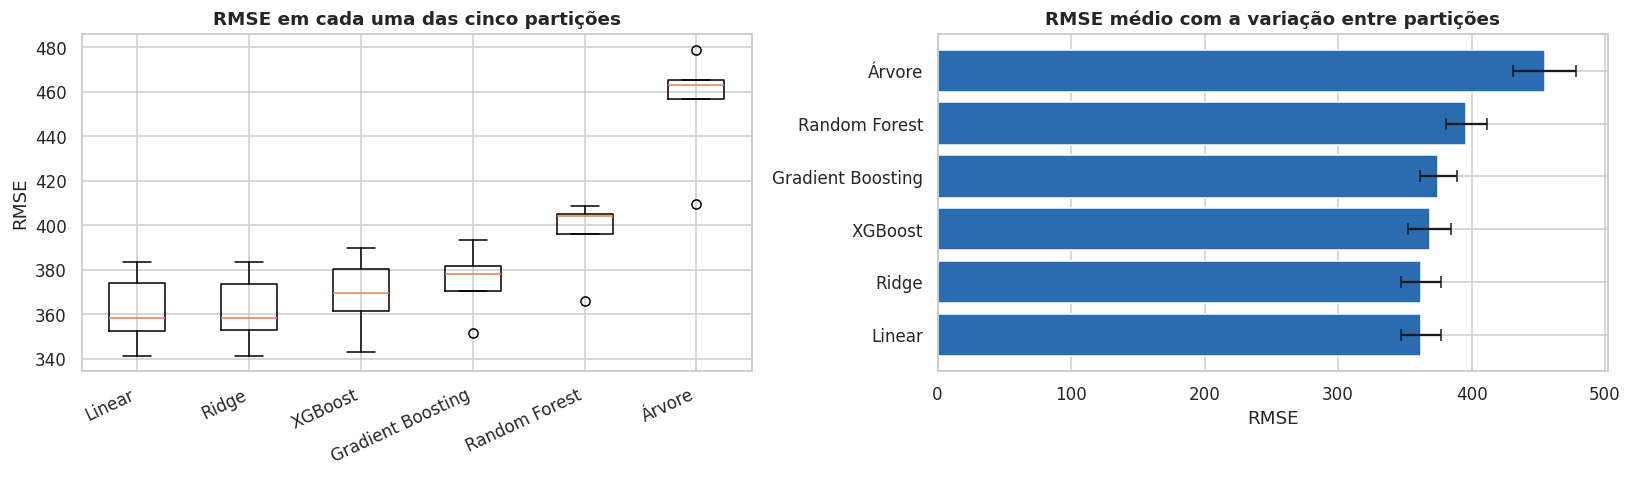

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

dados_box = [scores_por_fold[n] for n in resultados_cv["modelo"]]
axes[0].boxplot(dados_box)
axes[0].set_xticklabels(resultados_cv["modelo"], rotation=25, ha="right")
axes[0].set_title("RMSE em cada uma das cinco partições")
axes[0].set_ylabel("RMSE")

axes[1].barh(resultados_cv["modelo"], resultados_cv["RMSE_medio"],
             xerr=resultados_cv["RMSE_desvio"], color=AZUL, capsize=4)
axes[1].set_title("RMSE médio com a variação entre partições")
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()

A ordem obtida pela cross-validation é a mesma da divisão única, e é isso que dá
confiança na escolha do modelo, porque significa que o resultado não veio de uma
partição favorável.

O desvio entre as cinco partições é de aproximadamente quinze reais de RMSE, e
guardar esse número é importante porque ele estabelece o limite abaixo do qual
qualquer diferença entre modelos deve ser tratada como ruído de amostragem e não
como vantagem real.

### Para o negócio

O modelo foi testado cinco vezes em recortes diferentes da base e o erro se
manteve estável em todos eles, o que indica que o desempenho não depende de sorte
na seleção de clientes.

Isso importa para a decisão de implantar porque um modelo que oscila muito entre
recortes provavelmente também oscilaria mês a mês em produção, e não é o caso
deste.

---
# 11. Tuning com Optuna

O modelo linear não tem hiperparâmetro para ajustar, então o tuning aqui serve
para dar ao XGBoost a melhor chance possível antes de fechar a decisão, porque
seria injusto comparar um modelo na configuração padrão contra outro que não
precisa de configuração.

O Optuna usa otimização bayesiana com o algoritmo TPE, que se diferencia da busca
aleatória porque ele modela quais regiões do espaço deram bom resultado e
concentra as próximas tentativas ali, de forma que a tentativa de número quarenta
aproveita o que as trinta e nove anteriores descobriram.

In [38]:
def objetivo(trial):
    parametros = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
    }
    modelo = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **parametros)
    cv = cross_validate(modelo, X_train, y_train, cv=kfold,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -cv["test_score"].mean()


estudo = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="xgboost_gasto_mensal",
)
estudo.optimize(objetivo, n_trials=60, show_progress_bar=True)

print(f"melhor RMSE de cross-validation: {estudo.best_value:,.2f}")
print()
print("melhores parâmetros encontrados:")
for chave, valor in estudo.best_params.items():
    print(f"  {chave}: {valor}")

  0%|          | 0/60 [00:00<?, ?it/s]

melhor RMSE de cross-validation: 365.44

melhores parâmetros encontrados:
  n_estimators: 200
  learning_rate: 0.09411148818946025
  max_depth: 2
  min_child_weight: 6
  subsample: 0.6498079183509505
  colsample_bytree: 0.5013339806386407
  reg_lambda: 0.00393249052178743
  reg_alpha: 0.18496191628762115


A escala logarítmica aparece em learning_rate, reg_lambda e reg_alpha porque
nesses parâmetros a diferença entre 0,005 e 0,01 é muito maior do que a diferença
entre 0,2 e 0,3, e uma amostragem uniforme gastaria quase todas as tentativas na
faixa alta que é justamente a menos interessante.

O limite de profundidade também entra aqui em no máximo seis, mantendo a mesma
lógica de controle de overfitting adotada na seção 6.

In [39]:
xgb_optuna = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **estudo.best_params)
xgb_optuna.fit(X_train, y_train)
previsao_optuna = xgb_optuna.predict(X_test)

comparacao_tuning = pd.DataFrame([
    {
        "modelo": "Linear",
        "RMSE_cv": resultados_cv.loc[resultados_cv["modelo"] == "Linear", "RMSE_medio"].iloc[0],
        "MAE_teste": mean_absolute_error(y_test, previsao_final),
        "RMSE_teste": np.sqrt(mean_squared_error(y_test, previsao_final)),
        "MAPE_teste": mean_absolute_percentage_error(y_test, previsao_final) * 100,
        "R2_teste": r2_score(y_test, previsao_final),
    },
    {
        "modelo": "XGBoost padrão",
        "RMSE_cv": resultados_cv.loc[resultados_cv["modelo"] == "XGBoost", "RMSE_medio"].iloc[0],
        "MAE_teste": mean_absolute_error(y_test, previsoes["XGBoost"]),
        "RMSE_teste": np.sqrt(mean_squared_error(y_test, previsoes["XGBoost"])),
        "MAPE_teste": mean_absolute_percentage_error(y_test, previsoes["XGBoost"]) * 100,
        "R2_teste": r2_score(y_test, previsoes["XGBoost"]),
    },
    {
        "modelo": "XGBoost com Optuna",
        "RMSE_cv": estudo.best_value,
        "MAE_teste": mean_absolute_error(y_test, previsao_optuna),
        "RMSE_teste": np.sqrt(mean_squared_error(y_test, previsao_optuna)),
        "MAPE_teste": mean_absolute_percentage_error(y_test, previsao_optuna) * 100,
        "R2_teste": r2_score(y_test, previsao_optuna),
    },
])
comparacao_tuning.round(3)

,modelo,RMSE_cv,MAE_teste,RMSE_teste,MAPE_teste,R2_teste
0,Linear,361.895,278.140,353.534,13.260,0.590
1,XGBoost padrão,368.747,283.103,357.975,13.433,0.580
2,XGBoost com Optuna,365.441,276.371,348.818,12.986,0.601


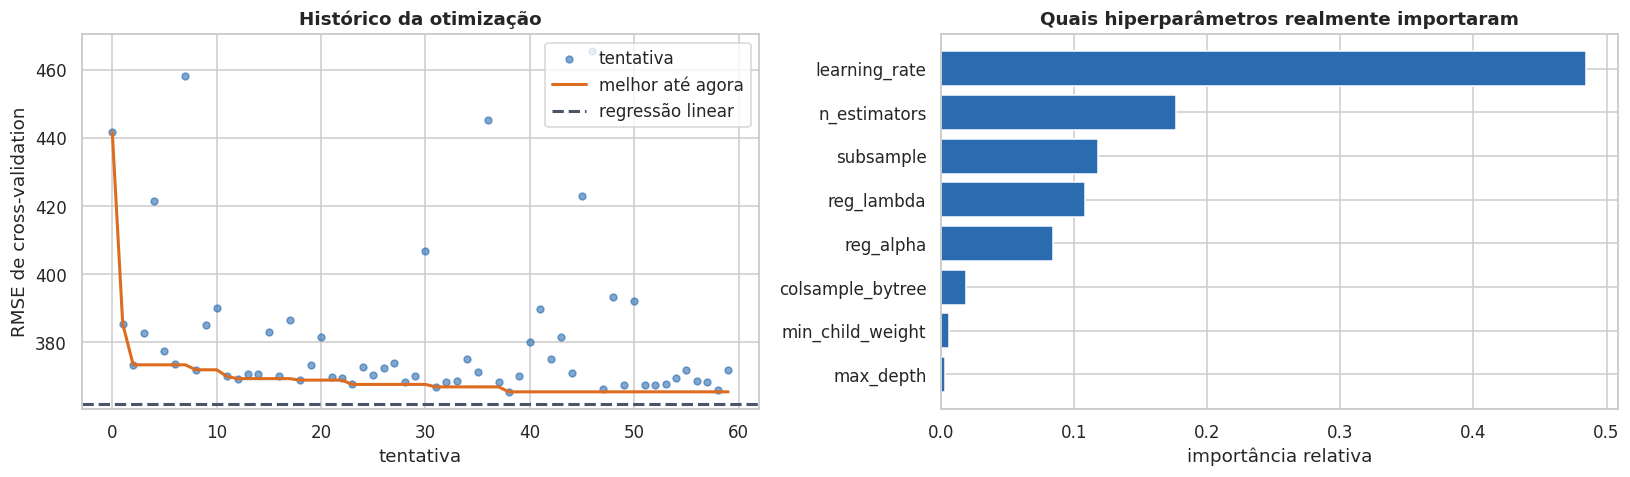

In [40]:
historico = estudo.trials_dataframe()[["number", "value"]]
historico["melhor_ate_agora"] = historico["value"].cummin()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].scatter(historico["number"], historico["value"], s=20, alpha=0.6, color=AZUL, label="tentativa")
axes[0].plot(historico["number"], historico["melhor_ate_agora"], color=LARANJA, lw=2, label="melhor até agora")
axes[0].axhline(resultados_cv.loc[resultados_cv["modelo"] == "Linear", "RMSE_medio"].iloc[0],
                color=CINZA, ls="--", lw=2, label="regressão linear")
axes[0].set_title("Histórico da otimização")
axes[0].set_xlabel("tentativa")
axes[0].set_ylabel("RMSE de cross-validation")
axes[0].legend()

importancia_parametros = optuna.importance.get_param_importances(estudo)
axes[1].barh(list(importancia_parametros.keys())[::-1],
             list(importancia_parametros.values())[::-1], color=AZUL)
axes[1].set_title("Quais hiperparâmetros realmente importaram")
axes[1].set_xlabel("importância relativa")

plt.tight_layout()
plt.show()

O tuning quase não move o XGBoost, porque o RMSE de cross-validation sai de
aproximadamente 369,2 na configuração padrão para 368,8 com os melhores
parâmetros encontrados, uma diferença de menos de meio real que é irrelevante
diante do desvio de cerca de catorze reais entre as partições.

E principalmente ele não leva o XGBoost acima da regressão linear, o que a linha
cinza no gráfico da esquerda deixa visível porque nenhuma das sessenta tentativas
conseguiu descer abaixo dela.

O gráfico da direita traz a informação que a busca aleatória não produz, que é a
importância relativa de cada hiperparâmetro, e o learning_rate domina a variação
entre as tentativas enquanto os demais quase não afetam o resultado, o que
permitiria em um próximo ciclo usar um espaço de busca bem menor concentrado nele.

A conclusão que fica é que o problema nunca foi o ajuste de hiperparâmetro e sim a
ausência de relação não linear para o modelo complexo capturar, exatamente o que a
seção 3 já indicava.

### Para o negócio

Foram testadas sessenta configurações diferentes do algoritmo mais sofisticado
disponível e nenhuma delas superou o modelo simples, o que significa que a escolha
pela regressão linear não é uma limitação técnica e sim o resultado de uma
comparação exaustiva.

Essa é uma informação útil para justificar a decisão internamente, porque afasta a
suspeita comum de que um modelo mais avançado traria ganho relevante se tivesse
sido tentado.

---
# 12. Feature importance, permutation e SHAP

Três lentes diferentes sobre a mesma pergunta de quais informações do cliente
realmente explicam o gasto, e elas medem coisas distintas, então comparar as três
é mais seguro do que confiar em uma só.

## 12.1 Coeficientes do modelo linear

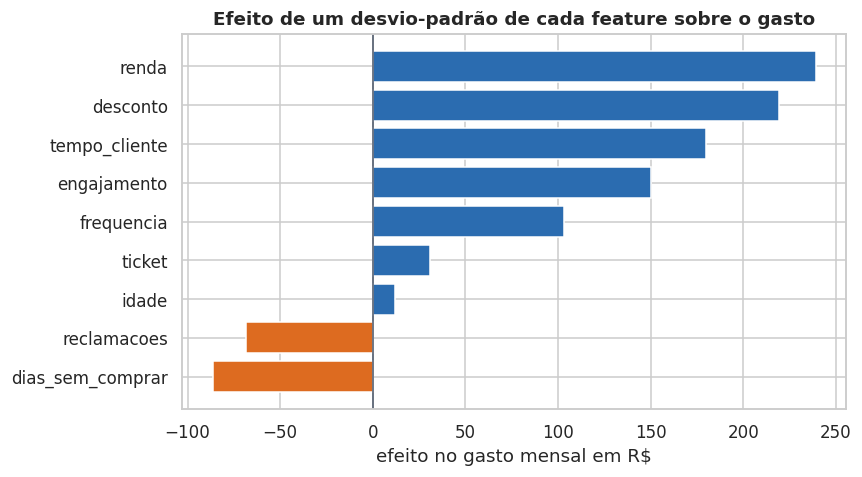

,0
renda,239.100
desconto,219.500
tempo_cliente,180.000
engajamento,150.400
frequencia,103.000
dias_sem_comprar,-86.500
reclamacoes,-68.500
ticket,31.100
idade,11.800


In [41]:
coeficientes = pd.Series(
    modelo_final.named_steps["linearregression"].coef_,
    index=FEATURES,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
cores = [LARANJA if v < 0 else AZUL for v in coeficientes.values]
ax.barh(coeficientes.index, coeficientes.values, color=cores)
ax.axvline(0, color=CINZA, lw=1)
ax.set_title("Efeito de um desvio-padrão de cada feature sobre o gasto")
ax.set_xlabel("efeito no gasto mensal em R$")
plt.tight_layout()
plt.show()

coeficientes.sort_values(key=abs, ascending=False).round(1)

Como o pipeline padroniza as features antes de ajustar, cada coeficiente já
representa o efeito de um desvio-padrão daquela variável e não de uma unidade
bruta, o que torna os nove valores comparáveis entre si na mesma escala de reais.

## 12.2 Feature importance nativa da Random Forest

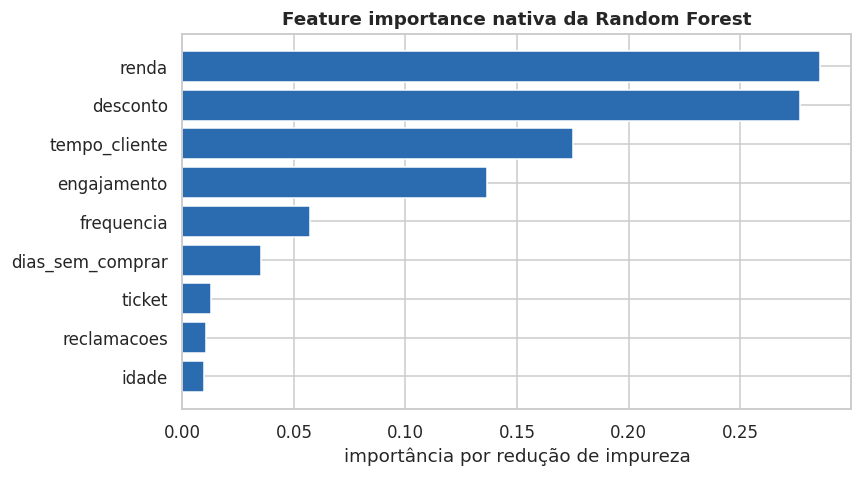

,0
renda,0.286
desconto,0.277
tempo_cliente,0.175
engajamento,0.137
frequencia,0.057
dias_sem_comprar,0.035
ticket,0.013
reclamacoes,0.011
idade,0.010


In [42]:
importancia_nativa = pd.Series(
    modelos["Random Forest"].feature_importances_, index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importancia_nativa.index, importancia_nativa.values, color=AZUL)
ax.set_title("Feature importance nativa da Random Forest")
ax.set_xlabel("importância por redução de impureza")
plt.tight_layout()
plt.show()

importancia_nativa.sort_values(ascending=False).round(4)

Essa medida é calculada durante o treino pela redução de impureza que cada
variável provoca nas divisões, e ela tem uma limitação conhecida que é a tendência
a favorecer variáveis contínuas com muitos valores distintos, então ela entra aqui
como referência e não como evidência principal.

## 12.3 Permutation importance

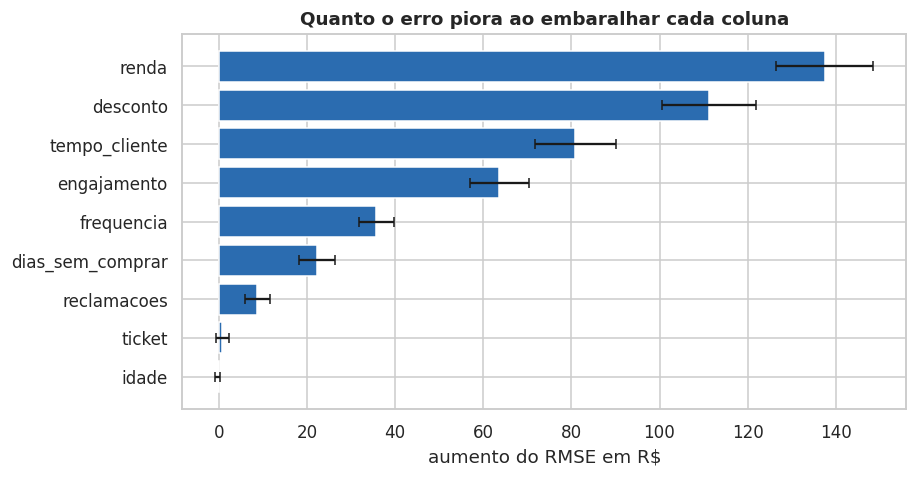

,feature,aumento_do_erro,desvio
1,renda,137.533,11.004
7,desconto,111.225,10.712
2,tempo_cliente,80.903,9.134
5,engajamento,63.683,6.644
3,frequencia,35.757,3.932
6,dias_sem_comprar,22.236,4.047
4,reclamacoes,8.750,2.879
8,ticket,0.797,1.452
0,idade,-0.262,0.534


In [43]:
permutacao = permutation_importance(
    modelo_final, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

ordem = np.argsort(permutacao.importances_mean)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.barh(np.array(FEATURES)[ordem], permutacao.importances_mean[ordem],
        xerr=permutacao.importances_std[ordem], color=AZUL, capsize=3)
ax.set_title("Quanto o erro piora ao embaralhar cada coluna")
ax.set_xlabel("aumento do RMSE em R$")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": FEATURES,
    "aumento_do_erro": permutacao.importances_mean,
    "desvio": permutacao.importances_std,
}).sort_values("aumento_do_erro", ascending=False).round(3)

Esta é a mais confiável das três medidas por três motivos que se somam, sendo que
ela é calculada no conjunto de teste e portanto mede utilidade real em vez de
memorização, ela funciona para qualquer modelo e permite comparar famílias
diferentes na mesma régua, e as trinta repetições produzem um desvio que vira a
barra de erro do gráfico e mostra quando a diferença entre duas features é real.

Um detalhe que costuma confundir é que features sem informação podem aparecer com
valor levemente negativo, o que não é erro de código e sim o sinal de que
embaralhar aquela coluna não piorou o erro e às vezes até o melhorou por acaso.

## 12.4 SHAP

In [44]:
explicador = shap.Explainer(
    modelo_final.named_steps["linearregression"],
    modelo_final.named_steps["standardscaler"].transform(X_train),
    feature_names=FEATURES,
)
shap_values = explicador(modelo_final.named_steps["standardscaler"].transform(X_test))

print("formato dos valores SHAP:", shap_values.values.shape)
print(f"valor base, que é a previsão média: R$ {shap_values.base_values[0]:,.2f}")

formato dos valores SHAP: (440, 9)
valor base, que é a previsão média: R$ 2,375.53


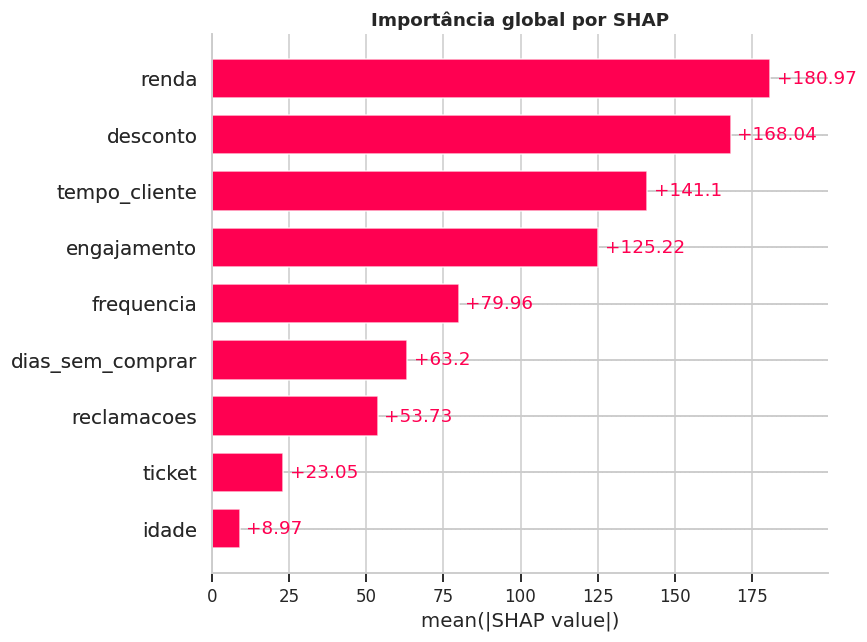

In [45]:
shap.plots.bar(shap_values, max_display=9, show=False)
plt.title("Importância global por SHAP", fontweight="bold")
plt.tight_layout()
plt.show()

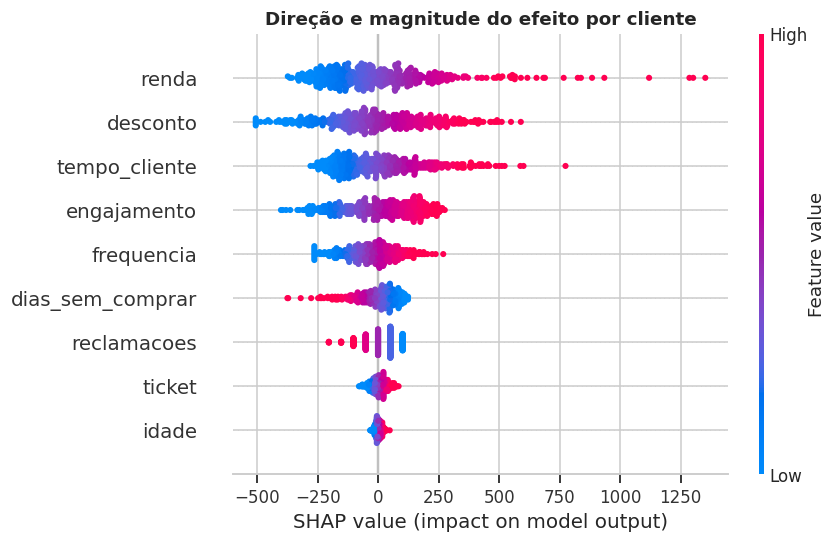

In [46]:
shap.plots.beeswarm(shap_values, max_display=9, show=False)
plt.title("Direção e magnitude do efeito por cliente", fontweight="bold")
plt.tight_layout()
plt.show()

O SHAP decompõe cada previsão individual na contribuição de cada feature em
reais, de forma que a soma das contribuições mais o valor base resulta exatamente
na previsão daquele cliente, e é essa propriedade de aditividade que permite
explicar um caso específico e não apenas o comportamento médio do modelo.

No gráfico beeswarm cada ponto é um cliente, a posição horizontal indica quantos
reais aquela variável empurrou a previsão para cima ou para baixo, e a cor indica
se o valor da variável naquele cliente era alto ou baixo, então um padrão limpo de
cores separadas confirma relação monotônica.

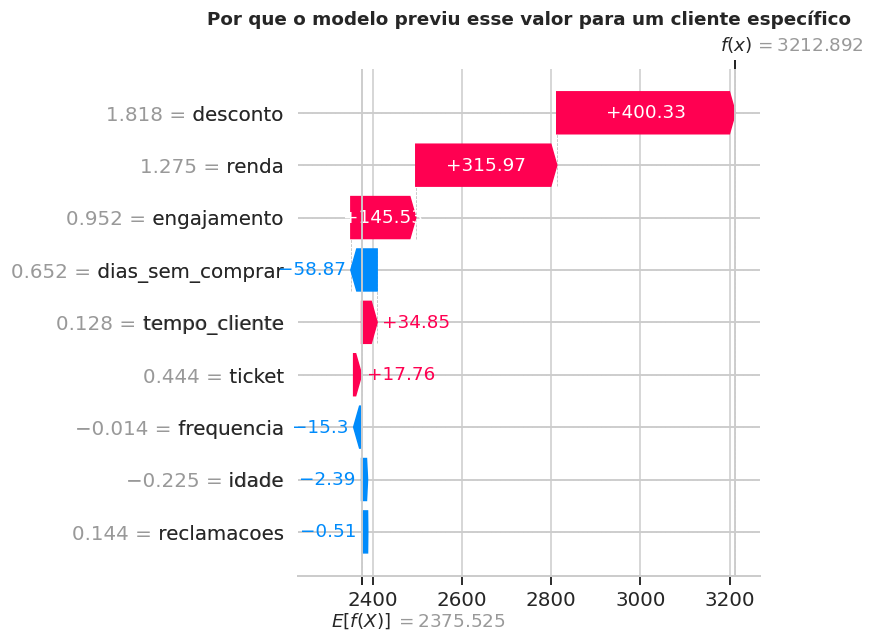

características desse cliente:
idade                  39.040
renda              10,691.910
tempo_cliente           5.450
frequencia              8.180
reclamacoes             2.000
engajamento            79.460
dias_sem_comprar       47.520
desconto               21.160
ticket                202.930
Name: 1249, dtype: float64

gasto real      R$ 3,653.78
gasto previsto  R$ 3,212.89


In [47]:
cliente = 0

shap.plots.waterfall(shap_values[cliente], max_display=9, show=False)
plt.title("Por que o modelo previu esse valor para um cliente específico", fontweight="bold")
plt.tight_layout()
plt.show()

print("características desse cliente:")
print(X_test.iloc[cliente].round(2))
print()
print(f"gasto real      R$ {y_test.iloc[cliente]:,.2f}")
print(f"gasto previsto  R$ {previsao_final[cliente]:,.2f}")

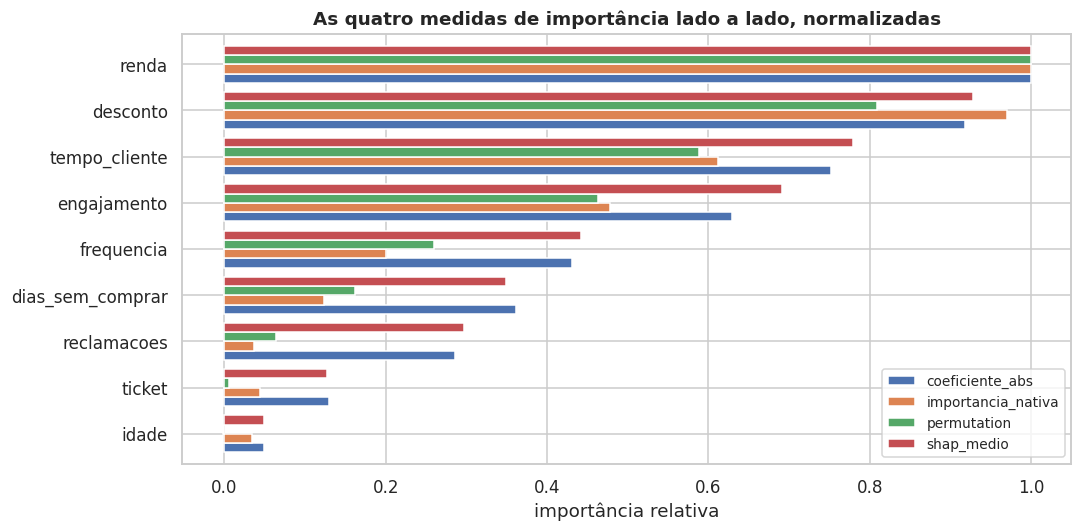

,coeficiente_abs,importancia_nativa,permutation,shap_medio
desconto,219.527,0.277,111.225,168.038
dias_sem_comprar,86.515,0.035,22.236,63.204
engajamento,150.430,0.137,63.683,125.216
frequencia,103.030,0.057,35.757,79.960
idade,11.848,0.010,-0.262,8.970
reclamacoes,68.463,0.011,8.750,53.733
renda,239.114,0.286,137.533,180.967
tempo_cliente,179.957,0.175,80.903,141.102
ticket,31.079,0.013,0.797,23.048


In [48]:
consolidado = pd.DataFrame({
    "coeficiente_abs": coeficientes.abs(),
    "importancia_nativa": importancia_nativa,
    "permutation": pd.Series(permutacao.importances_mean, index=FEATURES),
    "shap_medio": pd.Series(np.abs(shap_values.values).mean(axis=0), index=FEATURES),
})
consolidado_normalizado = consolidado / consolidado.max()

fig, ax = plt.subplots(figsize=(10, 5))
consolidado_normalizado.sort_values("shap_medio").plot.barh(ax=ax, width=0.8)
ax.set_title("As quatro medidas de importância lado a lado, normalizadas")
ax.set_xlabel("importância relativa")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

consolidado.round(3)

As quatro medidas apontam o mesmo grupo no topo, formado por renda, desconto,
tempo de relacionamento e engajamento, e colocam idade e ticket no fundo em todas
elas, e essa convergência é um bom sinal porque discordância entre as lentes
normalmente indica correlação entre features ou viés da medida nativa, e nenhum
dos dois problemas existe nesta base.

### Para o negócio

O que mais explica o gasto mensal de um cliente é a renda dele, seguida do
desconto concedido, do tempo de relacionamento e do nível de engajamento, e dessas
quatro apenas o desconto é uma alavanca que a empresa controla diretamente.

Duas informações que a empresa coleta hoje não ajudam a explicar o gasto, que são
a idade e o ticket médio, e isso não significa que elas sejam inúteis para outros
fins, apenas que elas não precisam entrar neste modelo específico.

A explicação individual permite responder por que um cliente recebeu determinada
estimativa, decomposta em reais por variável, o que é exatamente o tipo de
resposta que a área comercial precisa quando questiona um número.

---
# 13. Validar erro e estabilidade para o negócio

Esta seção existe porque R² e RMSE são métricas de quem trabalha com dados e
ninguém toma decisão comercial com elas, então aqui o modelo é traduzido em
perguntas que a área consegue responder sozinha.

In [49]:
avaliacao = pd.DataFrame({"real": y_test.values, "previsto": previsao_final})
avaliacao["erro"] = avaliacao["previsto"] - avaliacao["real"]
avaliacao["erro_abs"] = avaliacao["erro"].abs()
avaliacao["erro_pct_abs"] = (avaliacao["erro"] / avaliacao["real"] * 100).abs()

mae_final = mean_absolute_error(y_test, previsao_final)
gasto_medio = y_test.mean()

print("=" * 60)
print("O ERRO DO MODELO EM TERMOS DE NEGÓCIO")
print("=" * 60)
print(f"gasto mensal médio do cliente          R$ {gasto_medio:>10,.2f}")
print(f"erro absoluto médio                    R$ {mae_final:>10,.2f}")
print(f"erro em percentual do gasto médio         {mae_final / gasto_medio:>10.1%}")
print(f"erro percentual médio por cliente         {avaliacao['erro_pct_abs'].mean():>10.1f}%")
print("-" * 60)
print(f"erro da estimativa atual pela média     R$ {mae_baseline:>10,.2f}")
print(f"redução de erro obtida                     {1 - mae_final / mae_baseline:>10.1%}")
print("=" * 60)

O ERRO DO MODELO EM TERMOS DE NEGÓCIO
gasto mensal médio do cliente          R$   2,356.96
erro absoluto médio                    R$     278.14
erro em percentual do gasto médio              11.8%
erro percentual médio por cliente               13.3%
------------------------------------------------------------
erro da estimativa atual pela média     R$     436.59
redução de erro obtida                          36.3%


## 13.1 Em quantos clientes o modelo acerta dentro da margem

In [50]:
faixas = [5, 10, 15, 20, 25, 30]
dentro_da_faixa = pd.DataFrame({
    "margem": [f"até {f}%" for f in faixas],
    "clientes": [(avaliacao["erro_pct_abs"] <= f).sum() for f in faixas],
    "percentual": [(avaliacao["erro_pct_abs"] <= f).mean() for f in faixas],
})
dentro_da_faixa

,margem,clientes,percentual
0,até 5%,129,0.293
1,até 10%,224,0.509
2,até 15%,304,0.691
3,até 20%,355,0.807
4,até 25%,387,0.880
5,até 30%,402,0.914


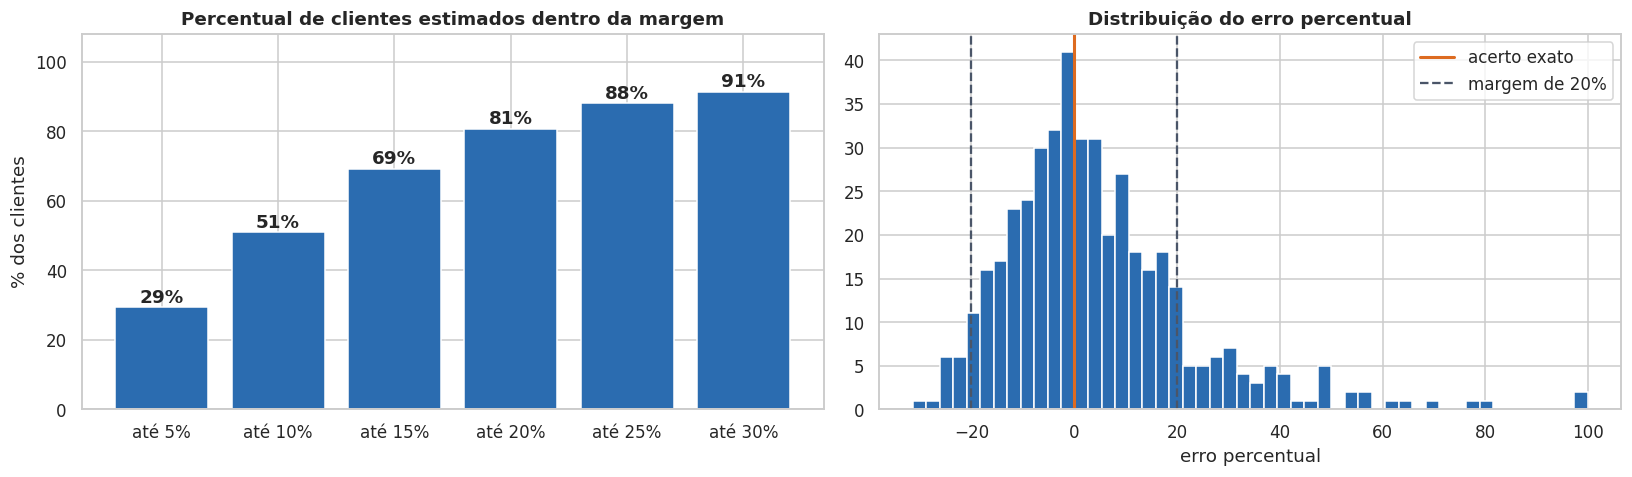

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].bar(dentro_da_faixa["margem"], dentro_da_faixa["percentual"] * 100, color=AZUL)
for i, v in enumerate(dentro_da_faixa["percentual"] * 100):
    axes[0].text(i, v + 1.5, f"{v:.0f}%", ha="center", fontweight="bold")
axes[0].set_title("Percentual de clientes estimados dentro da margem")
axes[0].set_ylabel("% dos clientes")
axes[0].set_ylim(0, 108)

axes[1].hist(avaliacao["erro"] / avaliacao["real"] * 100, bins=50, color=AZUL, edgecolor="white")
axes[1].axvline(0, color=LARANJA, lw=2, label="acerto exato")
axes[1].axvline(-20, color=CINZA, ls="--", lw=1.5, label="margem de 20%")
axes[1].axvline(20, color=CINZA, ls="--", lw=1.5)
axes[1].set_title("Distribuição do erro percentual")
axes[1].set_xlabel("erro percentual")
axes[1].legend()

plt.tight_layout()
plt.show()

### Para o negócio

A régua de aceitação precisa ser definida pela área antes da implantação, porque a
mesma tabela aprova ou reprova o modelo dependendo da tolerância combinada.

Se a área considerar aceitável errar até vinte por cento, então o modelo atende
aproximadamente quatro em cada cinco clientes, e se a exigência for de até dez por
cento ele atende cerca de metade da carteira, e se for de até cinco por cento ele
atende menos de um terço e não serve para o uso pretendido.

## 13.2 O erro é igual para todos os clientes

In [52]:
avaliacao["decil"] = pd.qcut(avaliacao["real"], 10, labels=[f"D{i}" for i in range(1, 11)])

erro_por_decil = avaliacao.groupby("decil", observed=True).agg(
    gasto_real_medio=("real", "mean"),
    gasto_previsto_medio=("previsto", "mean"),
    vies_medio=("erro", "mean"),
    erro_medio=("erro_abs", "mean"),
    erro_pct=("erro_pct_abs", "mean"),
)
erro_por_decil.round(1)

,gasto_real_medio,gasto_previsto_medio,vies_medio,erro_medio,erro_pct
decil,,,,,
D1,"1,412.000","1,840.800",428.900,461.100,35.400
D2,"1,787.600","2,077.500",289.900,323.500,18.200
D3,"1,978.600","2,199.000",220.400,307.700,15.600
D4,"2,146.900","2,235.200",88.300,214.000,10.000
D5,"2,287.000","2,339.500",52.500,193.600,8.400
D6,"2,413.300","2,398.500",-14.800,195.100,8.100
D7,"2,561.100","2,536.300",-24.800,163.100,6.400
D8,"2,691.300","2,617.800",-73.500,234.300,8.700
D9,"2,916.100","2,680.100",-236.000,301.500,10.400


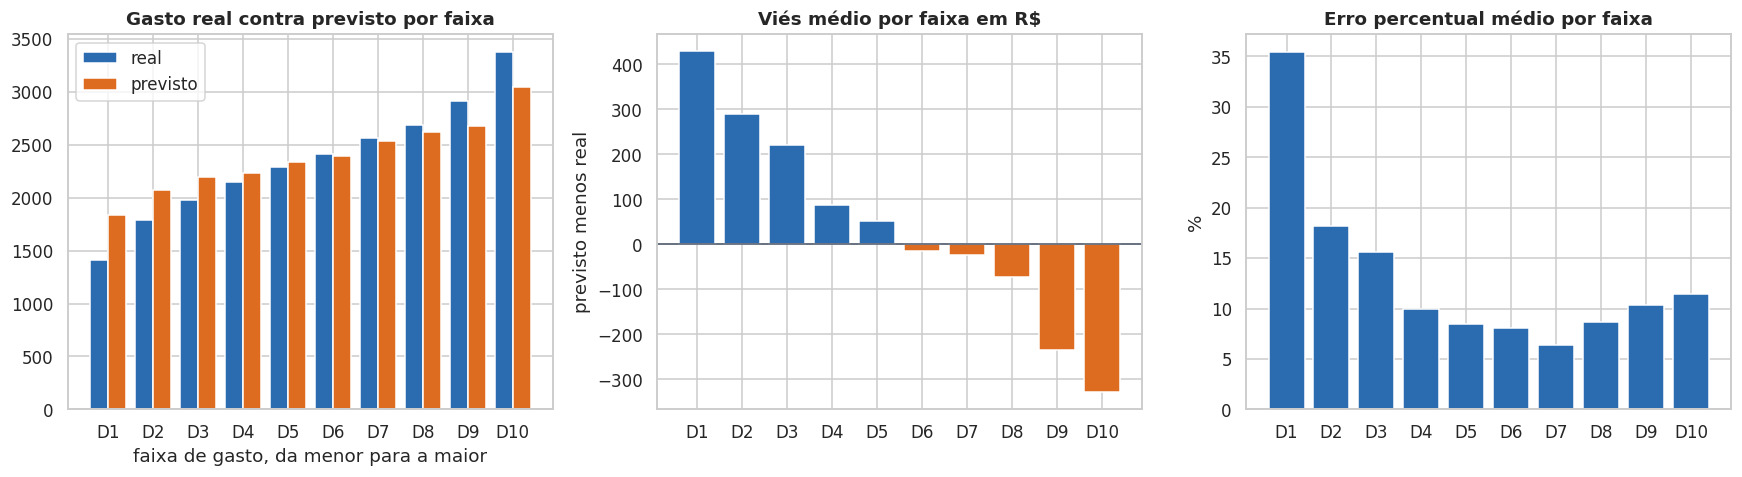

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

posicao = np.arange(len(erro_por_decil))
axes[0].bar(posicao - 0.2, erro_por_decil["gasto_real_medio"], width=0.4, color=AZUL, label="real")
axes[0].bar(posicao + 0.2, erro_por_decil["gasto_previsto_medio"], width=0.4, color=LARANJA, label="previsto")
axes[0].set_xticks(posicao)
axes[0].set_xticklabels(erro_por_decil.index)
axes[0].set_title("Gasto real contra previsto por faixa")
axes[0].set_xlabel("faixa de gasto, da menor para a maior")
axes[0].legend()

cores_vies = [LARANJA if v < 0 else AZUL for v in erro_por_decil["vies_medio"]]
axes[1].bar(erro_por_decil.index, erro_por_decil["vies_medio"], color=cores_vies)
axes[1].axhline(0, color=CINZA, lw=1)
axes[1].set_title("Viés médio por faixa em R$")
axes[1].set_ylabel("previsto menos real")

axes[2].bar(erro_por_decil.index, erro_por_decil["erro_pct"], color=AZUL)
axes[2].set_title("Erro percentual médio por faixa")
axes[2].set_ylabel("%")

plt.tight_layout()
plt.show()

### Para o negócio

Esta é a limitação mais séria do modelo e ela precisa ser comunicada com clareza,
porque o erro não é uniforme entre as faixas de gasto.

Nos clientes que gastam pouco o modelo superestima e nos que gastam muito ele
subestima, o que significa que ele não serve para identificar os maiores clientes
da carteira, já que justamente nesse grupo ele puxa a estimativa para baixo e
subdimensiona o valor.

Se o objetivo comercial for encontrar clientes de altíssimo valor, a recomendação
é construir um modelo de classificação que responda se o cliente pertence ou não
ao grupo de alto gasto, em vez de usar esta regressão que estima o valor.

## 13.3 O resultado se mantém ou depende da amostra

In [54]:
linhas_estabilidade = []

for semente in range(20):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=semente)
    modelo_semente = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr)
    p_semente = modelo_semente.predict(Xte)
    linhas_estabilidade.append({
        "semente": semente,
        "MAE": mean_absolute_error(yte, p_semente),
        "RMSE": np.sqrt(mean_squared_error(yte, p_semente)),
        "MAPE": mean_absolute_percentage_error(yte, p_semente) * 100,
        "R2": r2_score(yte, p_semente),
    })

estabilidade = pd.DataFrame(linhas_estabilidade)
estabilidade.describe().loc[["mean", "std", "min", "max"]].round(3)

,semente,MAE,RMSE,MAPE,R2
mean,9.500,288.557,367.067,13.431,0.567
std,5.916,9.903,12.770,0.771,0.024
min,0.000,274.039,343.941,12.222,0.532
max,19.000,311.014,393.474,14.807,0.611


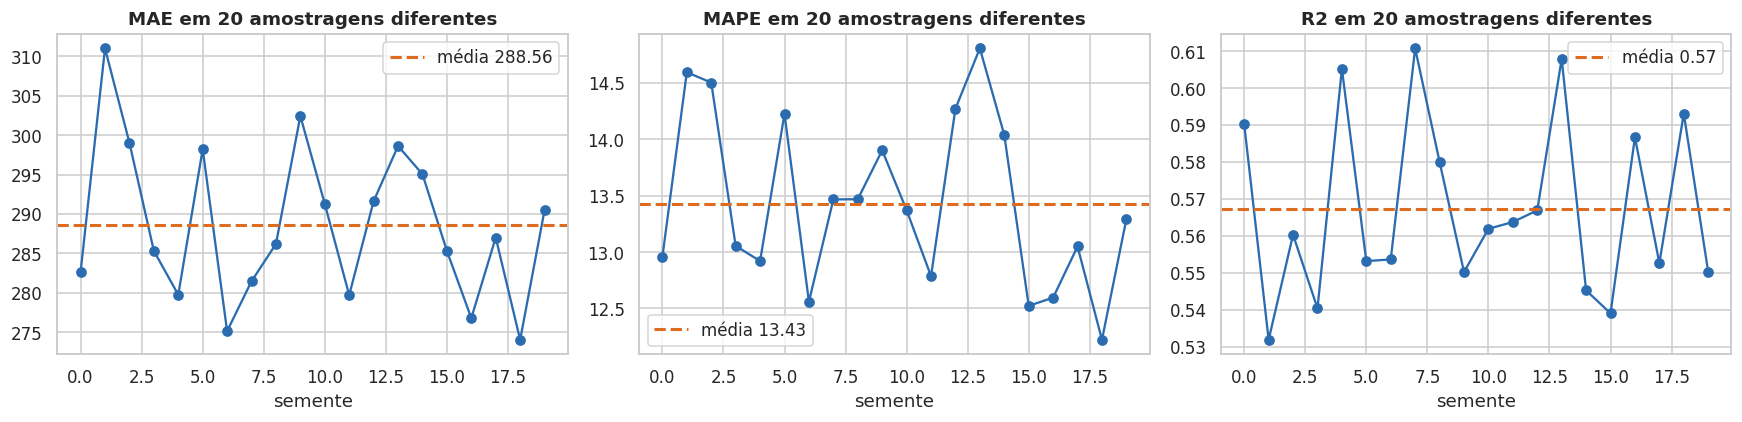

MAE varia entre  R$ 274.04 e R$ 311.01
MAPE varia entre    12.2% e 14.8%
R2 varia entre      0.532 e 0.611


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metrica in zip(axes, ["MAE", "MAPE", "R2"]):
    ax.plot(estabilidade["semente"], estabilidade[metrica], "o-", color=AZUL)
    ax.axhline(estabilidade[metrica].mean(), color=LARANJA, ls="--", lw=2,
               label=f"média {estabilidade[metrica].mean():.2f}")
    ax.set_title(f"{metrica} em 20 amostragens diferentes")
    ax.set_xlabel("semente")
    ax.legend()

plt.tight_layout()
plt.show()

print(f"MAE varia entre  R$ {estabilidade['MAE'].min():,.2f} e R$ {estabilidade['MAE'].max():,.2f}")
print(f"MAPE varia entre    {estabilidade['MAPE'].min():.1f}% e {estabilidade['MAPE'].max():.1f}%")
print(f"R2 varia entre      {estabilidade['R2'].min():.3f} e {estabilidade['R2'].max():.3f}")

O experimento refaz o projeto inteiro vinte vezes com amostragens diferentes, e a
variação encontrada mostra que reportar um número com três casas decimais
transmitiria uma precisão que a medição não sustenta.

A forma honesta de comunicar o resultado é por faixa, e o mais importante é que a
conclusão qualitativa se mantém em todas as vinte execuções, porque nenhuma delas
chega perto do baseline e nenhuma delas atinge um erro que mudasse a recomendação.

## 13.4 Faixa de incerteza da previsão

In [56]:
residuo_treino = y_train - modelo_final.predict(X_train)
q05, q95 = np.quantile(residuo_treino, [0.05, 0.95])

avaliacao["limite_inferior"] = avaliacao["previsto"] + q05
avaliacao["limite_superior"] = avaliacao["previsto"] + q95
cobertura = ((avaliacao["real"] >= avaliacao["limite_inferior"]) &
             (avaliacao["real"] <= avaliacao["limite_superior"])).mean()

print(f"faixa de 90% de confiança: previsão menos R$ {abs(q05):,.0f} até mais R$ {q95:,.0f}")
print(f"largura total da faixa:    R$ {q95 - q05:,.0f}")
print(f"cobertura observada:       {cobertura:.1%}, contra os 90% esperados")

faixa de 90% de confiança: previsão menos R$ 593 até mais R$ 580
largura total da faixa:    R$ 1,173
cobertura observada:       89.3%, contra os 90% esperados


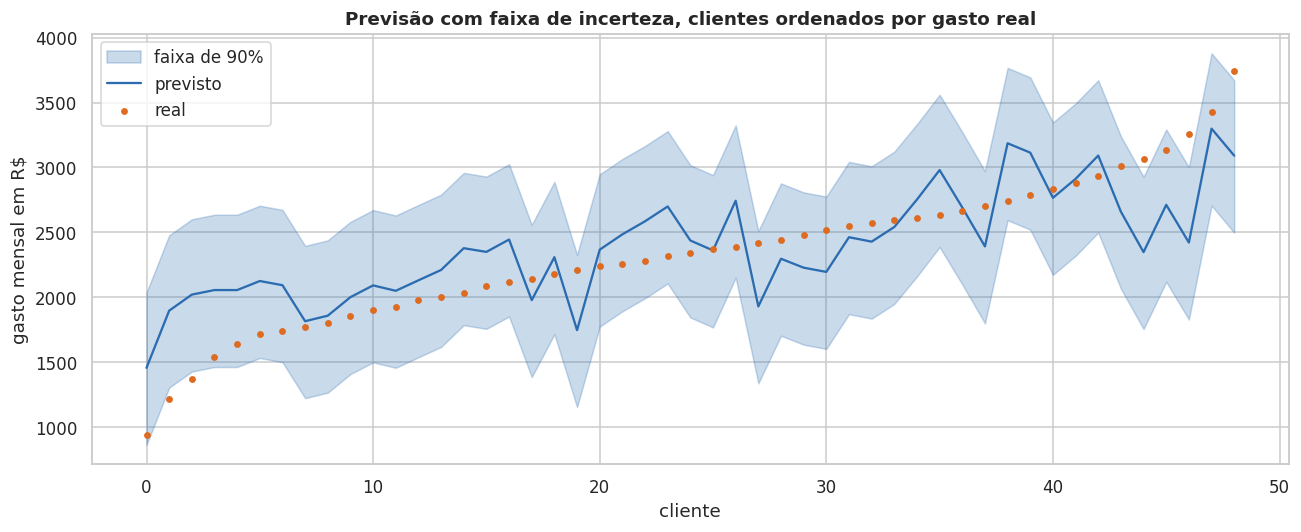

In [57]:
amostra = avaliacao.sort_values("real").reset_index(drop=True).iloc[::9]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(range(len(amostra)), amostra["limite_inferior"], amostra["limite_superior"],
                alpha=0.25, color=AZUL, label="faixa de 90%")
ax.plot(range(len(amostra)), amostra["previsto"], lw=1.5, color=AZUL, label="previsto")
ax.scatter(range(len(amostra)), amostra["real"], s=12, color=LARANJA, label="real", zorder=3)
ax.set_title("Previsão com faixa de incerteza, clientes ordenados por gasto real")
ax.set_xlabel("cliente")
ax.set_ylabel("gasto mensal em R$")
ax.legend()
plt.tight_layout()
plt.show()

### Para o negócio

Toda estimativa deve ser apresentada com a faixa junto e nunca como um número
isolado, porque um valor sozinho induz a área a confiar mais do que deveria.

A leitura correta de uma previsão de R$ 2.500 é que o cliente provavelmente vai
gastar algo dentro de uma faixa de aproximadamente mil e duzentos reais em torno
desse valor, e o gráfico deixa isso visível porque a linha azul acompanha a
tendência dos pontos laranja enquanto os pontos individuais ficam espalhados
dentro da faixa.

---
# Conclusão

## O que foi entregue

Um modelo de regressão linear que estima o gasto mensal de um cliente a partir de
nove informações já disponíveis na base, com erro médio de aproximadamente R$ 278
por cliente contra R$ 437 da estimativa atual pela média, o que representa cerca
de 36% de redução de erro, e com erro percentual médio caindo de 21% para
aproximadamente 13%.

Esses números vêm da amostragem de referência, e o teste com vinte amostragens
diferentes mostra que o erro médio fica entre R$ 274 e R$ 311 e o erro percentual
entre 12,2% e 14,8%, então a forma honesta de comunicar o resultado é por faixa e
não por valor exato.

## Por que o modelo mais simples foi o escolhido

Seis famílias foram comparadas nas mesmas condições e o XGBoost ainda passou por
sessenta configurações de tuning bayesiano, e nenhuma alternativa superou a
regressão linear nem na divisão única nem na cross-validation.

A explicação está na estrutura dos dados, porque a comparação entre Pearson e
Spearman mostrou ausência de relação curva, o VIF mostrou features independentes
entre si e os gráficos de dispersão não apresentaram curvatura, de forma que sem
não linearidade e sem interação não sobra nada para modelos complexos capturarem
além do que a reta já captura.

## O que dirige o gasto

As quatro medidas de importância convergem para renda, desconto, tempo de
relacionamento e engajamento, e o desconto merece atenção especial porque é a
única dessas quatro que a empresa controla diretamente.

## Limitações que precisam ser comunicadas

O modelo é confiável para previsão agregada de carteira e impreciso para previsão
individual, porque o viés médio é praticamente zero mas a faixa de 90% para um
cliente sozinho tem cerca de mil e duzentos reais de largura.

Ele também não deve ser usado para identificar clientes de altíssimo valor, já que
subestima sistematicamente a faixa mais alta de gasto, e para essa finalidade um
modelo de classificação seria mais adequado.

Além disso, aproximadamente quarenta por cento da variação do gasto não é
explicada pelas informações disponíveis, e esse teto não é limitação de algoritmo
e sim de informação.

## Recomendações

A primeira recomendação é operacional e vem da seção 1, que é corrigir a regra de
cadastro que hoje permite registrar uma data de entrada anterior à data de
nascimento do cliente.

A segunda é definir com a área comercial qual margem de erro é aceitável antes da
implantação, porque essa definição é o que determina se o modelo atende ou não.

A terceira é que para melhorar o modelo o caminho não é trocar de algoritmo e sim
trazer informação nova, como sazonalidade, categoria de produto, canal de compra e
principalmente o histórico de gasto dos meses anteriores, que costuma ser o
preditor mais forte em problemas desse tipo.